In [1]:
# SPDX-License-Identifier: Apache-2.0 AND CC-BY-NC-4.0
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Quantum Enhanced Optimization for Radar and Communications Applications 


The Low Autocorrelation Binary Sequences (LABS) is an important and challenging optimization problem with applications related to radar, telecommunications, and other signal related applications. This CUDA-Q Academic module will focus on a clever quantum-enhanced hybrid method developed in a collaboration between Kipu Quantum, University of the Basque Country EHU, and NVIDIA for solving the LABS problem. (This notebook was jointly developed with input from all collaborators.)

Other CUDA-Q Academic modules like [Divide and Conquer MaxCut QAOA](https://github.com/NVIDIA/cuda-q-academic/tree/main/qaoa-for-max-cut) and [Quantum Finance](https://github.com/NVIDIA/cuda-q-academic/blob/main/quantum-applications-to-finance/03_qchop.ipynb), demonstrate how quantum computing can be used outright to solve optimization problems. This notebook demonstrates a slightly different approach. Rather than considering QPUs as the tool to produce the final answer, it demonstrates how quantum can be used to enhance the effectiveness of leading classical methods.  

The benefits of such an approach were highlighted in [Scaling advantage with quantum-enhanced memetic tabu search for LABS](https://arxiv.org/html/2511.04553v1).  This notebook, co-created with the authors of the paper, will allow you to explore the findings of their research and write your own CUDA-Q code that builds a representative quantum-enhanced workflow for solving the LABS problem. Moreover, it will introduce advancements in counteradiabatic optimization techniques on which reduce the quantum resources required to run on a QPU.

**Prerequisites:** This lab assumes you have a basic knowledge of quantum computing, including operators, gates, etc.  For a refresher on some of these topics, explore the [Quick start to Quantum](https://github.com/NVIDIA/cuda-q-academic/tree/main/quick-start-to-quantum) series.

**In this lab you will:**
* 1. Understand the LABS problem and its relation ot radar and communication applications.
* 2. Solve LABS classically with memetic tabu search and learn about the limitations of such methods.
* 3. Code a couteradiabatic algorithm using CUDA-Q to produce approximate solutions to the LABS problem.
* 4. Use the CUDA-Q results to seed your tabu search and understand the potential benefits of this approach.


**Terminology you will use:**
* Low autocorrelation of binary sequences (LABS)
* counteradiabatic optimization
* memetic-tabu search

**CUDA-Q Syntax you will use:**
* cudaq.sample()
* @cudaq.kernel
* ry(), rx(), rz(), x(), h() 
* x.ctrl()

Run the code below to initialize the libraries you will need.

In [2]:
import cudaq
import numpy as np
from math import floor
import auxiliary_files.labs_utils as utils

/home/jovyan/.qbraid/environments/yd4s/pyenv/lib/python3.11/site-packages/cupy/_environment.py:596: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy-cuda12x, cupy-cuda13x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


## The LABS problem and applications

The **Low Autocorrelation Binary Sequences (LABS)** problem is fundamental to many applications, but originated with applications to radar. 

Consider a radar that monitors airport traffic.  The radar signal sent to detect incoming planes must have as much range as possible to ensure safe approaches are planned well in advance.  The range of a radar signal can be increased by sending a longer pulse.  However, in order to differentiate between multiple objects, pulses need to be short to provide high resolution. So, how do you handle situations where you need both?

One solution is a technique called pulse compression.  The idea is to send a long signal, but vary the phase at regular intervals such that the resolution is increased. Generally, the initial signal will encode a binary sequence of phase shifts, where each interval corresponds to a signal with a 0 or 180 degree phase shift. 

The tricky part is selecting an optimal encoding sequence.  When the signal returns, it is fed into a matched filter with the hope that a singular sharp peak will appear, indicating clear detection.  The autocorrelation of the original signal, or how similar the signal is to itself,  determines if a single peak or a messier signal with sidelobes will be detected. A signal should have high autocorrelation when overlayed on top of itself, but low autocorrelation when shifted with a lag. 

Consider the image below.  The signal on the left has a crisp single peak while the single on the right produces many undesirable sidelobes which can inhibit clear detection.  

<img src="images/quantum_enhanced_optimization_LABS/radar.png" width="800">


So, how do you select a good signal?   This is where LABS comes in, defining these questions as a binary optimization problem. Given a binary sequence of length $N$, $(s_1 \cdots s_N) \in {\pm 1}^N$, the goal is to minimize the following objective function.

$$ E(s) = \sum_{k=1}^{N-1} C_k^2 $$

Where $C_k$ is defined as. 

 $$C_k= \sum_{i=1}^{N-k} s_is_{i+k}$$


So, each $C_k$ computes how similar the original signal is to the shifted one for each offset value $k$.  To explore this more, try the interactive widget linked [here](https://nvidia.github.io/cuda-q-academic/interactive_widgets/labs_visualization.html).  See if you can select a very good and very poor sequence and see the difference for the case of $N=7$.

## Classical Solution of the LABS problem

The LABS problem is tricky to solve for a few reasons. First, the configuration space grows exponentially.  Second, underlying symmetries of the problem result in many degeneracies in the optimization landscape severely inhibiting local search methods. 

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 1:</h3>
    <p style="font-size: 16px; color: #333;">
Using the widget above, try to find some of the symmetries for the LABS problem. That is, for a fixed bitstring length, can you find patterns to produce the same energy with different pulse patterns. 
</div>

The best known performance for a classical optimization technique is Memetic Tabu search (MTS) which exhibits a scaling of $O(1.34^N)$.  The MTS algorithm is depicted below.  It begins with a randomly selected population of bitstrings and finds the best solution from them.  Then, a child is selected by sampling directly from or combining multiple bitstrings from the population.  The child is mutated with probability $p_{mutate}$ and then input to a tabu search, which performs a modified greedy local search starting from the child bitstring.  If the result is better than the best in the population, it is updated as the new leader and randomly replaces a  bitstring in the population.


<img src="images/quantum_enhanced_optimization_LABS/mts_algorithm.png" width="500">

Such an approach is fast, parallelizable, and allows for exploration with improved searching of the solution landscape.  

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 2:</h3>
    <p style="font-size: 16px; color: #333;">
Before exploring any quantum approach, get a sense for how MTS works by coding it yourself based generally on the figure above. Algorithms for the combine and mutate steps are provided below as used in the paper. You may need to research more specific details of the process, especially for how tabu search is performed. The MTS procedure should output and optimal bitstring and its energy.  Also, write a function to visualize the results including the energy distribution of the final population.
</div>



<img src="images/quantum_enhanced_optimization_LABS/combine_mutate.png" width="400">



### Answer for Exercise 1:

#### Bit negation will produce the same energy 

![](images/original-negation.png)

![](images/negation.png)

#### Bit reversal (of the order) will produce the same emergy
![](images/original-reversal.png)

![](images/reversal.png)

#### Bit negation + reversal will produce the same energy

![](images/original-negation-reversal.png)

![](images/negation-reversal.png)

#### Smallest we got clicking around

![](images/smallest.png)

The key is to find a sequence with the most "irregular" and unpredictable 
pattern. The known optimum for N=7 is $E=3$, which we found through 
exploration in the widget. This confirms the difficulty of LABS — even at 
small N, the optimal sequence requires a non-obvious mixed sign pattern.


### Answer to Exercise 2

In [3]:
"""
Exercise 2: Memetic Tabu Search (MTS) for LABS
MIT iQuHACK 2026 - NVIDIA LABS Challenge

Implements the MTS algorithm as described in:
"Scaling advantage with quantum-enhanced memetic tabu search for LABS"
(arXiv:2511.04553v1)
"""

import numpy as np
import random
import matplotlib.pyplot as plt
from typing import List, Tuple

# ============================================================
# LABS Energy Function
# ============================================================

def labs_energy(s: np.ndarray) -> int:
    """
    Compute LABS energy: E(s) = sum_{k=1}^{N-1} C_k^2
    where C_k = sum_{i=1}^{N-k} s_i * s_{i+k}
    """
    N = len(s)
    energy = 0
    for k in range(1, N):
        C_k = np.sum(s[:N-k] * s[k:])
        energy += C_k * C_k
    return int(energy)

# ============================================================
# MTS Components: Combine, Mutate, Tabu Search
# ============================================================

def combine(parent1: np.ndarray, parent2: np.ndarray) -> np.ndarray:
    """
    Uniform crossover: each bit selected from a random parent.
    (Algorithm 2 from the paper)
    """
    mask = np.random.randint(0, 2, size=len(parent1))
    child = np.where(mask, parent1, parent2)
    return child


def mutate(s: np.ndarray, p_mutate: float = 0.1) -> np.ndarray:
    """
    Flip each bit independently with probability p_mutate.
    (Algorithm 3 from the paper)
    """
    child = s.copy()
    flip_mask = np.random.random(len(child)) < p_mutate
    child[flip_mask] *= -1
    return child


def tabu_search(s: np.ndarray, 
                max_iter: int = 200, 
                tabu_tenure: int = 10) -> Tuple[np.ndarray, int]:
    """
    Greedy local search with tabu list to escape local minima.
    
    At each step:
    - Try flipping each bit
    - Pick the best non-tabu flip (or any flip that beats global best)
    - Mark that bit as tabu for `tabu_tenure` iterations
    """
    N = len(s)
    current = s.copy()
    current_energy = labs_energy(current)
    best = current.copy()
    best_energy = current_energy
    
    # tabu_list[i] is iteration number when bit i becomes available again
    tabu_list = np.zeros(N, dtype=int)
    
    for iteration in range(max_iter):
        best_flip_idx = -1
        best_flip_energy = float('inf')
        
        for i in range(N):
            # Flip bit i
            current[i] *= -1
            neighbor_energy = labs_energy(current)
            current[i] *= -1  # flip back
            
            # Accept if: (not tabu) OR (beats global best - aspiration criterion)
            is_tabu = tabu_list[i] > iteration
            beats_global = neighbor_energy < best_energy
            
            if (not is_tabu or beats_global) and neighbor_energy < best_flip_energy:
                best_flip_energy = neighbor_energy
                best_flip_idx = i
        
        if best_flip_idx == -1:
            break  # all moves tabu with no aspiration - stop
        
        # Apply best flip
        current[best_flip_idx] *= -1
        current_energy = best_flip_energy
        tabu_list[best_flip_idx] = iteration + tabu_tenure
        
        # Update global best
        if current_energy < best_energy:
            best = current.copy()
            best_energy = current_energy
    
    return best, best_energy


# ============================================================
# Full Memetic Tabu Search
# ============================================================

def memetic_tabu_search(N: int,
                        pop_size: int = 20,
                        max_generations: int = 100,
                        p_mutate: float = 0.1,
                        p_combine: float = 0.5,
                        tabu_iter: int = 200,
                        tabu_tenure: int = 10,
                        verbose: bool = True,
                        initial_population: list = None
                        ) -> Tuple[np.ndarray, int, List[int], list]:
    """
    Memetic Tabu Search for LABS.
    
    Args:
        N: Sequence length
        pop_size: Population size
        max_generations: Number of generations to run
        p_mutate: Mutation probability per bit
        p_combine: Probability of combining two parents vs copying one
        tabu_iter: Max iterations per tabu search call
        tabu_tenure: How long a bit stays tabu
        verbose: Print progress
        initial_population: Optional list of np.arrays to seed population
                           (this is what quantum enhancement will replace)
    
    Returns:
        best_sequence, best_energy, energy_history, final_population
    """
    # --- Initialize population ---
    if initial_population is not None:
        population = [np.array(s) for s in initial_population[:pop_size]]
        # Fill remaining slots randomly if needed
        while len(population) < pop_size:
            population.append(np.random.choice([-1, 1], size=N))
    else:
        population = [np.random.choice([-1, 1], size=N) for _ in range(pop_size)]
    
    energies = [labs_energy(s) for s in population]
    
    # Find initial best
    best_idx = int(np.argmin(energies))
    best = population[best_idx].copy()
    best_energy = energies[best_idx]
    
    energy_history = [best_energy]
    
    if verbose:
        print(f"Initial best energy: {best_energy}")
    
    # --- Main loop ---
    for gen in range(max_generations):
        # Select child
        if random.random() < p_combine and pop_size > 1:
            # Combine two random parents
            idx1, idx2 = random.sample(range(pop_size), 2)
            child = combine(population[idx1], population[idx2])
        else:
            # Copy a random parent
            idx = random.randint(0, pop_size - 1)
            child = population[idx].copy()
        
        # Mutate
        child = mutate(child, p_mutate)
        
        # Refine with tabu search
        refined, refined_energy = tabu_search(
            child, max_iter=tabu_iter, tabu_tenure=tabu_tenure
        )
        
        # If better than current best, update
        if refined_energy < best_energy:
            best = refined.copy()
            best_energy = refined_energy
            if verbose:
                print(f"  Gen {gen}: New best energy = {best_energy}")
        
        # Replace random population member with refined child
        replace_idx = random.randint(0, pop_size - 1)
        population[replace_idx] = refined
        energies[replace_idx] = refined_energy
        
        energy_history.append(best_energy)
    
    return best, best_energy, energy_history, population


# ============================================================
# Visualization
# ============================================================

def visualize_mts_results(energy_history: List[int], 
                          population: list,
                          title_prefix: str = "MTS"):
    """
    Two-panel visualization:
    - Left: convergence of best energy over generations
    - Right: energy distribution of final population
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    # Convergence
    axes[0].plot(energy_history, linewidth=2, color='#76b900')
    axes[0].set_xlabel('Generation', fontsize=12)
    axes[0].set_ylabel('Best Energy', fontsize=12)
    axes[0].set_title(f'{title_prefix} - Convergence', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    
    # Final population distribution
    final_energies = [labs_energy(s) for s in population]
    axes[1].hist(final_energies, bins=20, edgecolor='black', color='#76b900', alpha=0.7)
    axes[1].set_xlabel('Energy', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title(f'{title_prefix} - Final Population Distribution', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPopulation stats: min={min(final_energies)}, "
          f"median={int(np.median(final_energies))}, "
          f"max={max(final_energies)}")




TEST: N=7
Initial best energy: 3

Best: E=3, s=[-1 -1 -1  1  1 -1  1]


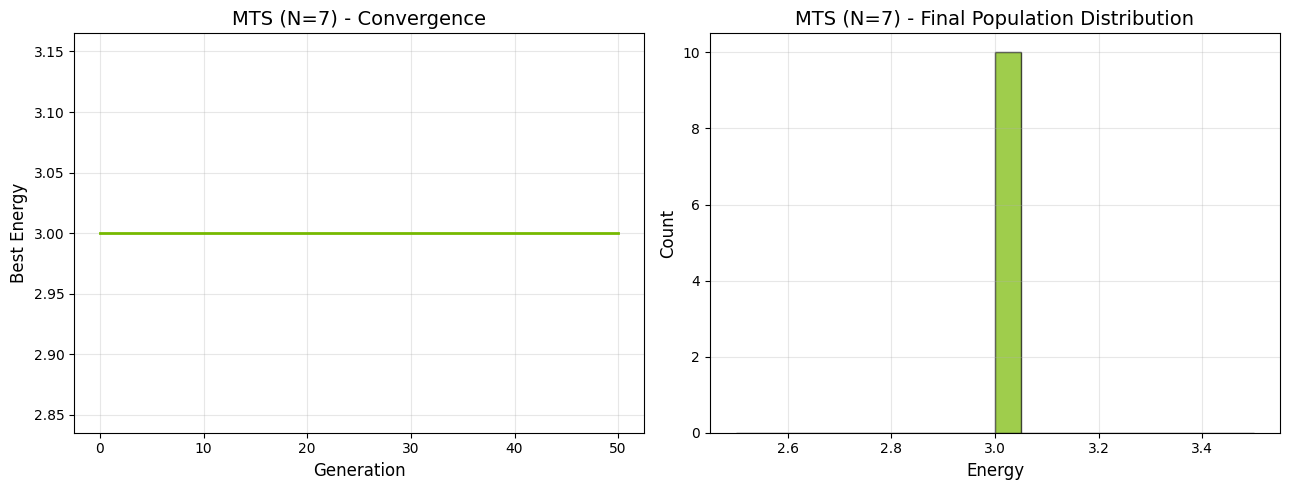


Population stats: min=3, median=3, max=3

TEST: N=20
Initial best energy: 86
  Gen 0: New best energy = 38
  Gen 4: New best energy = 34
  Gen 13: New best energy = 26

Best: E=26, s=[ 1  1  1  1  1 -1  1 -1 -1 -1  1 -1  1  1 -1 -1 -1  1  1 -1]


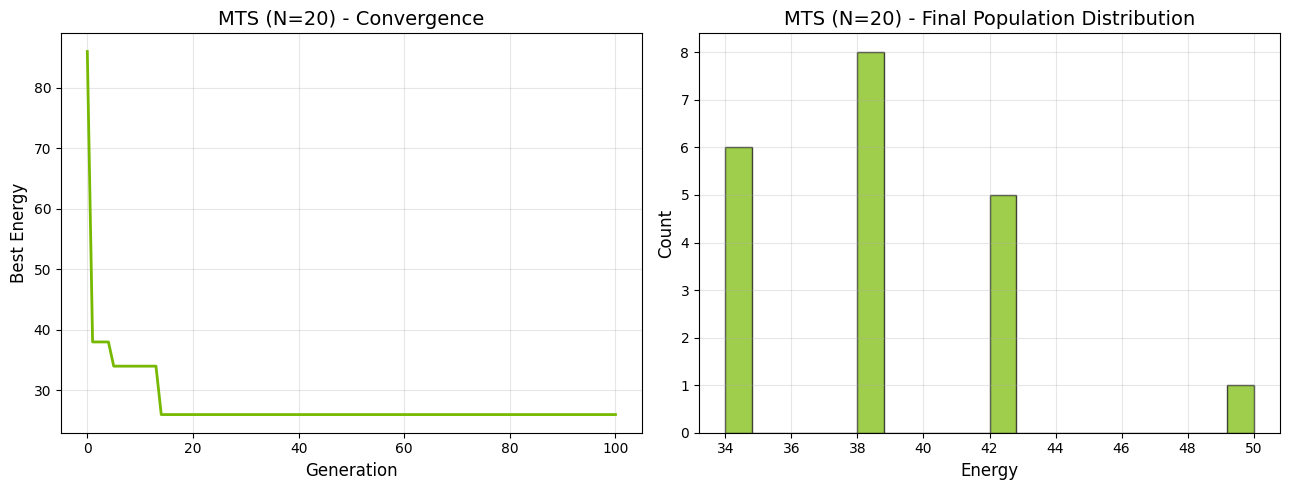


Population stats: min=34, median=38, max=50

VERIFY: Widget sequence
s = [ 1  1  1 -1 -1  1 -1]
E = 3


In [4]:
# ============================================================
# Run it
# ============================================================

# --- Small test: N=7 (found E=3 by hand) ---
print("=" * 50)
print("TEST: N=7")
print("=" * 50)
best_seq, best_energy, history, pop = memetic_tabu_search(
    N=7, pop_size=10, max_generations=50, verbose=True
)
print(f"\nBest: E={best_energy}, s={best_seq}")
visualize_mts_results(history, pop, title_prefix="MTS (N=7)")

# --- Challenge size: N=20 (matches tutorial default) ---
print("\n" + "=" * 50)
print("TEST: N=20")
print("=" * 50)
best_seq, best_energy, history, pop = memetic_tabu_search(
    N=20, pop_size=20, max_generations=100, verbose=True
)
print(f"\nBest: E={best_energy}, s={best_seq}")
visualize_mts_results(history, pop, title_prefix="MTS (N=20)")

# --- Verify your hand-calculated sequence ---
print("\n" + "=" * 50)
print("VERIFY: Widget sequence")
print("=" * 50)
seq = np.array([1, 1, 1, -1, -1, 1, -1])
print(f"s = {seq}")
print(f"E = {labs_energy(seq)}")  # Should be 3

## Building a Quantum Enhanced Workflow

Despite the effectiveness of MTS, it still exhibits exponential scaling  $O(1.34^N)$ behavior and becomes intractable for large $N$.  Quantum computing provides a potential alternative method for solving the LABS problem because the properties of entanglement, interference, and superpositon may allow for a better global search.  Recent demonstrations have even produced evidence that the quantum approximate optimization algorithm (QAOA) can be used to reduce the scaling of the LABS problem to $O(1.21^N)$ for $N$ between 28 and 40 with quantum minimum finding.

However, current quantum hardware limitations restrict solution to problems of greater than about $N=20$, meaning that it will be some time before quantum approaches can outperform the classical state of the art. It should also be noted that standard QAOA can struggle with LABS and require many layers to converge the parameters if other tricks are not employed.

The authors of [Scaling advantage with quantum-enhanced memetic tabu search for LABS](https://arxiv.org/html/2511.04553v1) cleverly explored an alternate path that combines quantum and classical approaches and might be able to provide a more near-term benefit.  Instead of expecting the quantum computer to solve the problem entirely, they asked how a quantum approach might enhance MTS.

The basic idea is that a quantum optimization routine could run first and the resulting state be sampled to produce a better population for MTS. Many such heuristics for defining the initial population are possible, but the rest of this notebook will explore their methodology, help you to build the workflow yourself, and allow you to analyze the benefits of their approach.

The first step of quantum enhanced MTS (QE-MTS) is to prepare a circuit with CUDA-Q that approximates the ground state of the Hamiltonian corresponding to the LABS problem. You could do this with any optimization algorithm such as QAOA or using an adiabatic approach.  (See the [Quantum Portfolio Optimization](https://github.com/NVIDIA/cuda-q-academic/blob/main/quantum-applications-to-finance/03_qchop.ipynb) CUDA-Q Academic lab for a detailed comparison of these two common approaches.)

The authors of this work opted for an adiabatic approach (More on why later). Recall that the goal of an adiabatic optimization is to begin with a Hamiltonian that has an easily prepared ground state ($H_i$). Then, the adiabatic Hamiltonian $H_{ad}$ can be constructed as $H_{ad}(\lambda) = (1-\lambda)H_i +\lambda H_f $, where $\lambda$ is a function of time and $H_f$ is the Hamiltonian representing a qubit encoding of the LABS problem. 

$$H_f = 2 \sum_{i=1}^{N-2} \sigma_i^z \sum_{k=1}^{\lfloor \frac{N-i}{2} \rfloor} \sigma_{i+k}^z 
+ 4 \sum_{i=1}^{N-3} \sigma_i^z \sum_{t=1}^{\lfloor \frac{N-i-1}{2} \rfloor} \sum_{k=t+1}^{N-i-t} \sigma_{i+t}^z \sigma_{i+k}^z \sigma_{i+k+t}^z$$

The authors also selected $H_i = \sum_i h^x_i \sigma^x_i $ which has an easily prepared ground state of $\ket{+}^{\otimes N}$.

The challenge for implementing the optimization procedure becomes selection of an operator that will quickly and accurately evolve to the ground state of $H_f$.  One approach is to use a so-called auxiliary countradiabatic (CD) term $H_{CD}$, which corrects diabatic transitions that jump out of the ground state during the evolution. The figure below demonstrates the benefit of using a CD correction.


<img src="images/quantum_enhanced_optimization_LABS/counteradiabatic.png" width="900">




An operator called the adiabatic gauge potential $A_{\lambda}$ is the ideal choice for the CD term as it suppresses all possible diabatic transitions, resulting in the following total system to evolve.

$$ H(\lambda) = H_{ad}(\lambda) + \lambda H_{CD} (\lambda) $$

$A(\lambda)$ is derrived from $H_{ad}(\lambda)$  (see paper for details) as it contains information about underlying physics of the problem. 

There is a problem though.  The $A(\lambda)$ term cannot be efficiently expressed exactly and needs to be approximated.  It also turns out that in the so called impulse regime, where the adiabatic evolution is very fast, $H_{cd} (\lambda)$ dominates $H_{ad}(\lambda)$, meaning that the final implementation corresponds to the operator $H(\lambda) = H^1_{cd}(\lambda)$ where  $H^1_{cd}(\lambda)$ is a first order approximation of $A(\lambda)$ (see equation 7 in the paper).

A final step is to use Trotterization to define the quantum circuit to apply $e^{-\theta (t) i H_{cd}}$. The details for this derivation are shown in the appendix of the paper. and result from equation B3 is shown below.  

$$
\begin{equation}
\begin{aligned}
U(0, T) = \prod_{n=1}^{n_{\text{trot}}} & \left[ \prod_{i=1}^{N-2} \prod_{k=1}^{\lfloor \frac{N-i}{2} \rfloor} R_{Y_i Z_{i+k}}\big(4\theta(n\Delta t)h_i^x\big) R_{Z_i Y_{i+k}}\big(4\theta(n\Delta t)h_{i+k}^x\big) \right] \\
& \times \prod_{i=1}^{N-3} \prod_{t=1}^{\lfloor \frac{N-i-1}{2} \rfloor} \prod_{k=t+1}^{N-i-t} \bigg( R_{Y_i Z_{i+t} Z_{i+k} Z_{i+k+t}}\big(8\theta(n\Delta t)h_i^x\big) \\
& \quad \times R_{Z_i Y_{i+t} Z_{i+k} Z_{i+k+t}}\big(8\theta(n\Delta t)h_{i+t}^x\big) \\
& \quad \times R_{Z_i Z_{i+t} Y_{i+k} Z_{i+k+t}}\big(8\theta(n\Delta t)h_{i+k}^x\big) \\
& \quad \times R_{Z_i Z_{i+t} Z_{i+k} Y_{i+k+t}}\big(8\theta(n\Delta t)h_{i+k+t}^x\big) \bigg)
\end{aligned}
\end{equation}
$$

It turns out that this implementation is more efficient than QAOA in terms of gate count. The authors calculated that for $N=67$, QAOA would require 1.4 million entangling gates while the CD approach derived here requires only 236 thousand entangling gates.


<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 3:</h3>
    <p style="font-size: 16px; color: #333;">
At first glance, this equation might looks quite complicated. However, observe the structure and note two "blocks" of terms.  Can you spot them?  

They are 2 qubit terms that look like $R_{YZ}(\theta)$ or $R_{ZY}(\theta)$.

As well as 4 qubit terms that look like $R_{YZZZ}(\theta)$, $R_{ZYZZ}(\theta)$, $R_{ZZYZ}(\theta)$, or $R_{ZZZY}(\theta)$.

Thankfully the authors derive a pair of circuit implementations for the two and four qubit terms respectively, shown in the figures below.

Using CUDA-Q, write a kernel for each which will be used later to construct the full implementation.

* Hint: Remember that the adjoint of a rotation gate is the same as rotating in the opposite direction. 

* Hint: You may also want to define a CUDA-Q kernel for an R$_{ZZ}$ gate.

* Hint: Implementing a circuit from a paper is a great place where AI can help accelerate your work.  If you have access to a coding assistant, feel free to use it here.
</div>

<img src="images/quantum_enhanced_optimization_LABS/kernels.png" width="1300">


### Answer to Exercise 3

In [5]:
"""
Exercise 3: CUDA-Q Kernels for Counteradiabatic Circuit
MIT iQuHACK 2026 - NVIDIA LABS Challenge

Building blocks for the Trotterized counteradiabatic evolution.
Based on circuit diagrams from arXiv:2511.04553v1, Appendix B.

Key insight: All multi-Pauli rotations R_{P1 P2 ... Pn}(θ) decompose as:
  1. Rotate any Y-qubits into the Z basis:  Rx(-π/2)
  2. CNOT cascade to entangle parity onto one qubit
  3. Rz(θ) on that qubit
  4. Undo CNOT cascade
  5. Undo basis rotation:  Rx(+π/2)

The adjoint of a rotation is just the opposite angle (hint from tutorial).
"""

import cudaq
import numpy as np

# ============================================================
# Helper: RZZ gate (used inside the 2-qubit and 4-qubit blocks)
# ============================================================

@cudaq.kernel
def rzz_gate(q0: cudaq.qubit, q1: cudaq.qubit, theta: float):
    """
    R_ZZ(θ) = exp(-i θ/2 Z⊗Z)
    
    Circuit:
        q0 ──●──────────●──
             │          │
        q1 ──X── Rz(θ) ─X──
    """
    x.ctrl(q0, q1)
    rz(theta, q1)
    x.ctrl(q0, q1)


# ============================================================
# 2-Qubit Kernels: R_YZ and R_ZY
# ============================================================

@cudaq.kernel
def r_yz(q0: cudaq.qubit, q1: cudaq.qubit, theta: float):
    """
    R_YZ(θ) = exp(-i θ/2 Y⊗Z)
    
    Rotate q0 from Y basis to Z basis, apply ZZ, rotate back.
    
    Circuit:
        q0 ── Rx(-π/2) ──●────────────●── Rx(π/2) ──
                         │            │
        q1 ──────────────X── Rz(θ) ──X────────────── 
    """
    rx(-np.pi / 2, q0)    # Y → Z basis change
    x.ctrl(q0, q1)
    rz(theta, q1)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q0)     # undo basis change


@cudaq.kernel
def r_zy(q0: cudaq.qubit, q1: cudaq.qubit, theta: float):
    """
    R_ZY(θ) = exp(-i θ/2 Z⊗Y)
    
    Same as R_YZ but the Y acts on q1 instead of q0.
    
    Circuit:
        q0 ──────────────●────────────●──────────────
                         │            │
        q1 ── Rx(-π/2) ──X── Rz(θ) ──X── Rx(π/2) ──
    """
    rx(-np.pi / 2, q1)
    x.ctrl(q0, q1)
    rz(theta, q1)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q1)


# ============================================================
# 4-Qubit Kernels: R_YZZZ, R_ZYZZ, R_ZZYZ, R_ZZZY
# ============================================================
#
# Pattern: exactly ONE qubit gets Y, the rest get Z.
# The Y-qubit gets basis-changed with Rx(±π/2).
# All qubits participate in a CNOT cascade.
#
# CNOT cascade for 4 qubits:
#   q0 ──●─────────────────────────────●──
#        │                             │
#   q1 ──X──●───────────────────●──X───── 
#           │                   │
#   q2 ─────X──●─────────●──X──────────── 
#              │         │
#   q3 ────────X── Rz ──X─────────────────
#
# (CNOTs chain the parity down to q3, Rz there, then undo)

@cudaq.kernel
def r_yzzz(q0: cudaq.qubit, q1: cudaq.qubit, 
           q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    """R_YZZZ(θ): Y on q0, Z on q1,q2,q3"""
    rx(-np.pi / 2, q0)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q0)


@cudaq.kernel
def r_zyzz(q0: cudaq.qubit, q1: cudaq.qubit, 
           q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    """R_ZYZZ(θ): Z on q0, Y on q1, Z on q2,q3"""
    rx(-np.pi / 2, q1)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q1)


@cudaq.kernel
def r_zzyz(q0: cudaq.qubit, q1: cudaq.qubit, 
           q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    """R_ZZYZ(θ): Z on q0,q1, Y on q2, Z on q3"""
    rx(-np.pi / 2, q2)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q2)


@cudaq.kernel
def r_zzzy(q0: cudaq.qubit, q1: cudaq.qubit, 
           q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    """R_ZZZY(θ): Z on q0,q1,q2, Y on q3"""
    rx(-np.pi / 2, q3)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q3)

In [6]:
"""
Exercise 3 - Verification Tests
Run this on qBraid to confirm your kernels work before moving on.
"""

import cudaq
import numpy as np

# ============================================================
# Helper to safely get count from cudaq SampleResult
# ============================================================
def get_count(result, bitstring):
    """Safely get count for a bitstring from cudaq SampleResult"""
    try:
        return result.count(bitstring)
    except:
        return 0

# ============================================================
# Paste your kernels here (or import them)
# ============================================================

@cudaq.kernel
def rzz_gate(q0: cudaq.qubit, q1: cudaq.qubit, theta: float):
    x.ctrl(q0, q1)
    rz(theta, q1)
    x.ctrl(q0, q1)

@cudaq.kernel
def r_yz(q0: cudaq.qubit, q1: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q0)
    x.ctrl(q0, q1)
    rz(theta, q1)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q0)

@cudaq.kernel
def r_zy(q0: cudaq.qubit, q1: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q1)
    x.ctrl(q0, q1)
    rz(theta, q1)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q1)

@cudaq.kernel
def r_yzzz(q0: cudaq.qubit, q1: cudaq.qubit, q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q0)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q0)

@cudaq.kernel
def r_zyzz(q0: cudaq.qubit, q1: cudaq.qubit, q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q1)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q1)

@cudaq.kernel
def r_zzyz(q0: cudaq.qubit, q1: cudaq.qubit, q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q2)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q2)

@cudaq.kernel
def r_zzzy(q0: cudaq.qubit, q1: cudaq.qubit, q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q3)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q3)


# ============================================================
# TEST 1: Identity check — theta=0 should do nothing
# ============================================================
print("=" * 50)
print("TEST 1: theta=0 should leave |00> unchanged")
print("=" * 50)

@cudaq.kernel
def test_ryz_zero():
    q = cudaq.qvector(2)
    r_yz(q[0], q[1], 0.0)

result = cudaq.sample(test_ryz_zero, shots_count=1000)
print(f"R_YZ(0) on |00>: {result}")
count_00 = get_count(result, "00")
print(f"  Expected: ~100% |00>")
print(f"  Got |00>: {count_00 / 10}%")


# ============================================================
# TEST 2: Large rotation check — theta=pi should flip things
# ============================================================
print("\n" + "=" * 50)
print("TEST 2: R_YZ(pi) on |00> — should create superposition")
print("=" * 50)

@cudaq.kernel
def test_ryz_pi():
    q = cudaq.qvector(2)
    r_yz(q[0], q[1], np.pi)

result = cudaq.sample(test_ryz_pi, shots_count=1000)
count_00 = get_count(result, "00")
print(f"R_YZ(π) on |00>: {result}")
print(f"  Should see a mix of states (not all |00>)")
print(f"  Got |00>: {count_00 / 10}%")


# ============================================================
# TEST 3: Symmetry — R_YZ and R_ZY should differ
# ============================================================
print("\n" + "=" * 50)
print("TEST 3: R_YZ vs R_ZY — should give different results")
print("=" * 50)

@cudaq.kernel
def test_rzy_pi():
    q = cudaq.qvector(2)
    r_zy(q[0], q[1], np.pi)

result_yz = cudaq.sample(test_ryz_pi, shots_count=1000)
result_zy = cudaq.sample(test_rzy_pi, shots_count=1000)
print(f"R_YZ(π): {result_yz}")
print(f"R_ZY(π): {result_zy}")
print(f"  These should differ (Y acts on different qubit)")


# ============================================================
# TEST 4: 4-qubit kernel — theta=0 identity check
# ============================================================
print("\n" + "=" * 50)
print("TEST 4: 4-qubit R_YZZZ(0) should leave |0000> unchanged")
print("=" * 50)

@cudaq.kernel
def test_4q_zero():
    q = cudaq.qvector(4)
    r_yzzz(q[0], q[1], q[2], q[3], 0.0)

result = cudaq.sample(test_4q_zero, shots_count=1000)
count_0000 = get_count(result, "0000")
print(f"R_YZZZ(0) on |0000>: {result}")
print(f"  Expected: ~100% |0000>")
print(f"  Got |0000>: {count_0000 / 10}%")


# ============================================================
# TEST 5: 4-qubit kernel — nonzero rotation
# ============================================================
print("\n" + "=" * 50)
print("TEST 5: 4-qubit R_YZZZ(pi) on |0000>")
print("=" * 50)

@cudaq.kernel
def test_4q_pi():
    q = cudaq.qvector(4)
    r_yzzz(q[0], q[1], q[2], q[3], np.pi)

result = cudaq.sample(test_4q_pi, shots_count=1000)
count_0000 = get_count(result, "0000")
print(f"R_YZZZ(π) on |0000>: {result}")
print(f"  Should see superposition (not all |0000>)")
print(f"  Got |0000>: {count_0000 / 10}%")


# ============================================================
# TEST 6: All four 4-qubit variants — verify they differ
# ============================================================
print("\n" + "=" * 50)
print("TEST 6: All 4-qubit variants with theta=pi/2")
print("=" * 50)

@cudaq.kernel
def test_yzzz():
    q = cudaq.qvector(4)
    r_yzzz(q[0], q[1], q[2], q[3], np.pi / 2)

@cudaq.kernel
def test_zyzz():
    q = cudaq.qvector(4)
    r_zyzz(q[0], q[1], q[2], q[3], np.pi / 2)

@cudaq.kernel
def test_zzyz():
    q = cudaq.qvector(4)
    r_zzyz(q[0], q[1], q[2], q[3], np.pi / 2)

@cudaq.kernel
def test_zzzy():
    q = cudaq.qvector(4)
    r_zzzy(q[0], q[1], q[2], q[3], np.pi / 2)

for name, kernel in [("YZZZ", test_yzzz), ("ZYZZ", test_zyzz), 
                      ("ZZYZ", test_zzyz), ("ZZZY", test_zzzy)]:
    result = cudaq.sample(kernel, shots_count=1000)
    print(f"R_{name}(π/2): {result}")


# ============================================================
# TEST 7 (BONUS): Draw a circuit if cudaq.draw is available
# ============================================================
print("\n" + "=" * 50)
print("TEST 7: Circuit visualization (if available)")
print("=" * 50)

try:
    print("\nR_YZ(π) circuit:")
    print(cudaq.draw(test_ryz_pi))
    print("\nR_YZZZ(π) circuit:")
    print(cudaq.draw(test_4q_pi))
except Exception as e:
    print(f"cudaq.draw not available: {e}")
    print("(This is fine — the sampling tests above are sufficient)")


print("\n" + "=" * 50)
print("ALL TESTS COMPLETE")
print("=" * 50)
print("""
What to check:
  ✓ Tests 1,4: theta=0 → ~100% ground state (identity)
  ✓ Tests 2,5: theta=pi → deterministic flip of Y-qubit (rotation happened)
  ✓ Test 3: R_YZ ≠ R_ZY (Y acts on different qubit)
  ✓ Test 6: All four 4-qubit variants give different distributions
  ✓ Test 7: Circuit diagrams match paper (if draw works)
""")

TEST 1: theta=0 should leave |00> unchanged
R_YZ(0) on |00>: { 00:1000 }

  Expected: ~100% |00>
  Got |00>: 100.0%

TEST 2: R_YZ(pi) on |00> — should create superposition
R_YZ(π) on |00>: { 10:1000 }

  Should see a mix of states (not all |00>)
  Got |00>: 0.0%

TEST 3: R_YZ vs R_ZY — should give different results
R_YZ(π): { 10:1000 }

R_ZY(π): { 01:1000 }

  These should differ (Y acts on different qubit)

TEST 4: 4-qubit R_YZZZ(0) should leave |0000> unchanged
R_YZZZ(0) on |0000>: { 0000:1000 }

  Expected: ~100% |0000>
  Got |0000>: 100.0%

TEST 5: 4-qubit R_YZZZ(pi) on |0000>
R_YZZZ(π) on |0000>: { 1000:1000 }

  Should see superposition (not all |0000>)
  Got |0000>: 0.0%

TEST 6: All 4-qubit variants with theta=pi/2
R_YZZZ(π/2): { 0000:484 1000:516 }

R_ZYZZ(π/2): { 0000:510 0100:490 }

R_ZZYZ(π/2): { 0000:506 0010:494 }

R_ZZZY(π/2): { 0000:526 0001:474 }


TEST 7: Circuit visualization (if available)

R_YZ(π) circuit:
     ╭────────────╮                       ╭───────────╮
q0 

There are a few additional items we need to consider before completing the final implementation of the entire circuit.  One simplification we can make is that for our problem the $h_i^x$ terms are all 1 and any $h_b^x$ terms are 0, and are only there for generalizations of this model. 

The remaining challenge is derivation of the angles that are used to apply each of the circuits you defined above. These are obtained from two terms $\lambda(t)$ and $\alpha(t)$.  


The $\lambda(t)$ defines an annealing schedule and is generally a Sin function which slowly "turns on" the problem Hamiltonian.  For computing our angles, we need the derivative of $\lambda(t)$.

The $\alpha$ term is a bit trickier and is the solution to a set of differential equations which minimize the distance between $H^1_{CD}(\lambda)$ and $A(\lambda)$.  The result is 

$$\alpha(t) = \frac{-\Gamma_1(t)}{\Gamma_2(t)} $$

Where $\Gamma_1(t)$ and $\Gamma_2(t)$ are defined in equations 16 and 17 of the paper and essentially depend on the structure of the optimization problem.  Curious learners can look at the functions in `labs_utils.py`  to see how these are computed, based on the problem size and specific time step in the Trotter process. 


<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 4:</h3>
    <p style="font-size: 16px; color: #333;">
The `compute_theta` function, called in the following cells, requires all indices of the two and four body terms. These will be used again in our main kernel to apply the respective gates.  Use the products in the formula below to finish the function in the cell below.  Save them as `G2` and `G4` where each is a list of lists of indices defining the two and four term interactions. As you are translating an equation to a set of loops, this is a great opportunity to use an AI coding assistant.

$$
\begin{equation}
\begin{aligned}
U(0, T) = \prod_{n=1}^{n_{\text{trot}}} & \left[ \prod_{i=1}^{N-2} \prod_{k=1}^{\lfloor \frac{N-i}{2} \rfloor} R_{Y_i Z_{i+k}}\big(4\theta(n\Delta t)h_i^x\big) R_{Z_i Y_{i+k}}\big(4\theta(n\Delta t)h_{i+k}^x\big) \right] \\
& \times \prod_{i=1}^{N-3} \prod_{t=1}^{\lfloor \frac{N-i-1}{2} \rfloor} \prod_{k=t+1}^{N-i-t} \bigg( R_{Y_i Z_{i+t} Z_{i+k} Z_{i+k+t}}\big(8\theta(n\Delta t)h_i^x\big) \\
& \quad \times R_{Z_i Y_{i+t} Z_{i+k} Z_{i+k+t}}\big(8\theta(n\Delta t)h_{i+t}^x\big) \\
& \quad \times R_{Z_i Z_{i+t} Y_{i+k} Z_{i+k+t}}\big(8\theta(n\Delta t)h_{i+k}^x\big) \\
& \quad \times R_{Z_i Z_{i+t} Z_{i+k} Y_{i+k+t}}\big(8\theta(n\Delta t)h_{i+k+t}^x\big) \bigg)
\end{aligned}
\end{equation}
$$

</div>


### Answer to Exercise 4

In [7]:
"""
Exercise 4: Generate G2 and G4 Interaction Indices
MIT iQuHACK 2026 - NVIDIA LABS Challenge

Translates the loop structure from Equation 15 (arXiv:2511.04553v1)
into 0-indexed qubit indices for the CUDA-Q circuit.

The Trotterized circuit has two types of terms:

  2-body (G2): R_YZ and R_ZY acting on qubits [i, i+k]
    Paper (1-indexed): i in 1..N-2,  k in 1..floor((N-i)/2)
    Code (0-indexed):  i in 0..N-3,  k in 1..floor((N-i-1)/2)

  4-body (G4): R_YZZZ etc. acting on qubits [i, i+t, i+k, i+k+t]
    Paper (1-indexed): i in 1..N-3,  t in 1..floor((N-i-1)/2),  k in t+1..N-i-t
    Code (0-indexed):  i in 0..N-4,  t in 1..floor((N-i-2)/2),  k in t+1..N-i-1-t
"""

from math import floor

def get_interactions(N):
    """
    Generates the interaction sets G2 and G4 based on the loop limits in Eq. 15.
    Returns standard 0-based indices as lists of lists of ints.
    
    Args:
        N (int): Sequence length.
        
    Returns:
        G2: List of [i, i+k] pairs for two-body terms
        G4: List of [i, i+t, i+k, i+k+t] quads for four-body terms
    """
    
    G2 = []
    for i in range(N - 2):  # 0-indexed: 0 to N-3
        for k in range(1, (N - i - 1) // 2 + 1):
            G2.append([i, i + k])
    
    G4 = []
    for i in range(N - 3):  # 0-indexed: 0 to N-4
        for t in range(1, (N - i - 2) // 2 + 1):
            for k in range(t + 1, N - i - t):
                G4.append([i, i + t, i + k, i + k + t])
    
    return G2, G4


# ============================================================
# Verification
# ============================================================

# --- N=4: Small enough to check by hand ---
print("=" * 50)
print("N=4")
print("=" * 50)
G2, G4 = get_interactions(4)
print(f"G2 ({len(G2)} terms): {G2}")
print(f"G4 ({len(G4)} terms): {G4}")
print()
print("Expected G2 (from equation, converted to 0-indexed):")
print("  i=0: k=1 → [0, 1]")
print("  i=1: k=1 → [1, 2]")
print("  = [[0,1], [1,2]]")
print()
print("Expected G4: i goes 0 to N-4=0")
print("  i=0: t=1 to floor((4-0-2)/2)=1")
print("    t=1: k from 2 to 4-0-1-1=2 → k=2")
print("      [0, 1, 2, 3]")
print("  = [[0, 1, 2, 3]]")


# --- N=7: Match against paper ---
print("\n" + "=" * 50)
print("N=7")
print("=" * 50)
G2, G4 = get_interactions(7)
print(f"G2 ({len(G2)} terms):")
for pair in G2:
    print(f"  {pair}")
print(f"\nG4 ({len(G4)} terms):")
for quad in G4:
    print(f"  {quad}")


# --- N=20: Production size (matches tutorial default) ---
print("\n" + "=" * 50)
print("N=20")
print("=" * 50)
G2, G4 = get_interactions(20)
print(f"G2: {len(G2)} two-body terms")
print(f"G4: {len(G4)} four-body terms")
print(f"Total gate blocks per Trotter step: {len(G2)*2 + len(G4)*4}")
print(f"  (G2 contributes 2 gates each: R_YZ + R_ZY)")
print(f"  (G4 contributes 4 gates each: R_YZZZ + R_ZYZZ + R_ZZYZ + R_ZZZY)")


# --- Sanity checks ---
print("\n" + "=" * 50)
print("SANITY CHECKS")
print("=" * 50)

for N_test in [4, 7, 10, 20]:
    G2, G4 = get_interactions(N_test)
    
    # All indices should be in range [0, N-1]
    all_g2_indices = [idx for pair in G2 for idx in pair]
    all_g4_indices = [idx for quad in G4 for idx in quad]
    all_indices = all_g2_indices + all_g4_indices
    
    in_range = all(0 <= idx < N_test for idx in all_indices)
    
    # G2 pairs should have exactly 2 elements
    g2_sizes_ok = all(len(pair) == 2 for pair in G2)
    
    # G4 quads should have exactly 4 elements
    g4_sizes_ok = all(len(quad) == 4 for quad in G4)
    
    # No duplicate indices within any single term
    g2_no_dups = all(len(set(pair)) == 2 for pair in G2)
    g4_no_dups = all(len(set(quad)) == 4 for quad in G4)
    
    status = "✓" if all([in_range, g2_sizes_ok, g4_sizes_ok, g2_no_dups, g4_no_dups]) else "✗"
    print(f"N={N_test:3d}: G2={len(G2):4d}, G4={len(G4):5d}, "
          f"range_ok={in_range}, sizes_ok={g2_sizes_ok and g4_sizes_ok}, "
          f"no_dups={g2_no_dups and g4_no_dups} {status}")

N=4
G2 (2 terms): [[0, 1], [1, 2]]
G4 (1 terms): [[0, 1, 2, 3]]

Expected G2 (from equation, converted to 0-indexed):
  i=0: k=1 → [0, 1]
  i=1: k=1 → [1, 2]
  = [[0,1], [1,2]]

Expected G4: i goes 0 to N-4=0
  i=0: t=1 to floor((4-0-2)/2)=1
    t=1: k from 2 to 4-0-1-1=2 → k=2
      [0, 1, 2, 3]
  = [[0, 1, 2, 3]]

N=7
G2 (9 terms):
  [0, 1]
  [0, 2]
  [0, 3]
  [1, 2]
  [1, 3]
  [2, 3]
  [2, 4]
  [3, 4]
  [4, 5]

G4 (13 terms):
  [0, 1, 2, 3]
  [0, 1, 3, 4]
  [0, 1, 4, 5]
  [0, 1, 5, 6]
  [0, 2, 3, 5]
  [0, 2, 4, 6]
  [1, 2, 3, 4]
  [1, 2, 4, 5]
  [1, 2, 5, 6]
  [1, 3, 4, 6]
  [2, 3, 4, 5]
  [2, 3, 5, 6]
  [3, 4, 5, 6]

N=20
G2: 90 two-body terms
G4: 525 four-body terms
Total gate blocks per Trotter step: 2280
  (G2 contributes 2 gates each: R_YZ + R_ZY)
  (G4 contributes 4 gates each: R_YZZZ + R_ZYZZ + R_ZZYZ + R_ZZZY)

SANITY CHECKS
N=  4: G2=   2, G4=    1, range_ok=True, sizes_ok=True, no_dups=True ✓
N=  7: G2=   9, G4=   13, range_ok=True, sizes_ok=True, no_dups=True ✓
N= 10: G2=



<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 5:</h3>
    <p style="font-size: 16px; color: #333;">
You are now ready to construct the entire circuit and run the counteradiabatic optimization procedure. The final kernel needs to apply Equation 15 for a specified total evolution time $T$ and the `n_steps` number of Trotter steps.  It must also take as input, the indices for the two and four body terms and the thetas to be applied each step, as these cannot be computed within a CUDA-Q kernel.

The helper function `compute_theta` computes the theta parameters for you, using a few additional functions in accordance with the equations defined in the paper.
</div>


### Answer to Exercise 5

In [8]:
"""
Exercise 5: Full Trotterized Counteradiabatic Circuit
MIT iQuHACK 2026 - NVIDIA LABS Challenge

Assembles the complete circuit from Equation 15 (arXiv:2511.04553v1):

  U(0,T) = prod_{n=1}^{n_trot} [
      prod over G2 terms:  R_YZ(4θ·h_i^x) · R_ZY(4θ·h_{i+k}^x)
    × prod over G4 terms:  R_YZZZ(8θ·h_i^x) · R_ZYZZ(8θ·h_{i+t}^x) 
                          · R_ZZYZ(8θ·h_{i+k}^x) · R_ZZZY(8θ·h_{i+k+t}^x)
  ]

Simplification from the tutorial: all h_i^x = 1 (and h_b^x = 0),
so the angle prefactors become just 4θ and 8θ.
"""

import cudaq
import numpy as np
import auxiliary_files.labs_utils as utils
from math import floor


# ============================================================
# Kernels from Exercise 3
# ============================================================

@cudaq.kernel
def r_yz(q0: cudaq.qubit, q1: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q0)
    x.ctrl(q0, q1)
    rz(theta, q1)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q0)

@cudaq.kernel
def r_zy(q0: cudaq.qubit, q1: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q1)
    x.ctrl(q0, q1)
    rz(theta, q1)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q1)

@cudaq.kernel
def r_yzzz(q0: cudaq.qubit, q1: cudaq.qubit, q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q0)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q0)

@cudaq.kernel
def r_zyzz(q0: cudaq.qubit, q1: cudaq.qubit, q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q1)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q1)

@cudaq.kernel
def r_zzyz(q0: cudaq.qubit, q1: cudaq.qubit, q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q2)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q2)

@cudaq.kernel
def r_zzzy(q0: cudaq.qubit, q1: cudaq.qubit, q2: cudaq.qubit, q3: cudaq.qubit, theta: float):
    rx(-np.pi / 2, q3)
    x.ctrl(q0, q1)
    x.ctrl(q1, q2)
    x.ctrl(q2, q3)
    rz(theta, q3)
    x.ctrl(q2, q3)
    x.ctrl(q1, q2)
    x.ctrl(q0, q1)
    rx(np.pi / 2, q3)


# ============================================================
# G2/G4 from Exercise 4
# ============================================================

def get_interactions(N):
    G2 = []
    for i in range(N - 2):
        for k in range(1, (N - i - 1) // 2 + 1):
            G2.append([i, i + k])
    
    G4 = []
    for i in range(N - 3):
        for t in range(1, (N - i - 2) // 2 + 1):
            for k in range(t + 1, N - i - t):
                G4.append([i, i + t, i + k, i + k + t])
    
    return G2, G4


# ============================================================
# Exercise 5: Full Trotterized Circuit
# ============================================================

@cudaq.kernel
def trotterized_circuit(N: int, G2: list[list[int]], G4: list[list[int]], 
                        steps: int, dt: float, T: float, 
                        thetas: list[float]):
    """
    Full counteradiabatic Trotterized evolution for LABS.
    
    Args:
        N: Number of qubits (= sequence length)
        G2: Two-body interaction indices [[i, j], ...]
        G4: Four-body interaction indices [[i, j, k, l], ...]
        steps: Number of Trotter steps
        dt: Time step size (T / steps)
        T: Total evolution time
        thetas: Pre-computed theta values, one per Trotter step
    """
    reg = cudaq.qvector(N)
    
    # Initialize in |+>^N (ground state of H_i = sum sigma_x)
    h(reg)
    
    # Trotter steps
    for step in range(steps):
        theta = thetas[step]
        
        # --- Two-body terms ---
        # Each G2 pair [i, i+k] produces:
        #   R_YZ(4θ)  on qubits [i, i+k]    (h_i^x = 1)
        #   R_ZY(4θ)  on qubits [i, i+k]    (h_{i+k}^x = 1)
        for pair_idx in range(len(G2)):
            qi = G2[pair_idx][0]
            qj = G2[pair_idx][1]
            r_yz(reg[qi], reg[qj], 4.0 * theta)
            r_zy(reg[qi], reg[qj], 4.0 * theta)
        
        # --- Four-body terms ---
        # Each G4 quad [i, i+t, i+k, i+k+t] produces:
        #   R_YZZZ(8θ)  (Y on qubit i)
        #   R_ZYZZ(8θ)  (Y on qubit i+t)
        #   R_ZZYZ(8θ)  (Y on qubit i+k)
        #   R_ZZZY(8θ)  (Y on qubit i+k+t)
        for quad_idx in range(len(G4)):
            qi = G4[quad_idx][0]
            qj = G4[quad_idx][1]
            qk = G4[quad_idx][2]
            ql = G4[quad_idx][3]
            r_yzzz(reg[qi], reg[qj], reg[qk], reg[ql], 8.0 * theta)
            r_zyzz(reg[qi], reg[qj], reg[qk], reg[ql], 8.0 * theta)
            r_zzyz(reg[qi], reg[qj], reg[qk], reg[ql], 8.0 * theta)
            r_zzzy(reg[qi], reg[qj], reg[qk], reg[ql], 8.0 * theta)


# ============================================================
# Setup and Run
# ============================================================

T = 5               # total evolution time
n_steps = 10         # number of Trotter steps
dt = T / n_steps
N = 12

G2, G4 = get_interactions(N)

# Compute theta for each Trotter step using the utility function
thetas = []
for step in range(1, n_steps + 1):
    t = step * dt
    theta_val = utils.compute_theta(t, dt, T, N, G2, G4)
    thetas.append(theta_val)

print(f"N = {N}")
print(f"Trotter steps = {n_steps}")
print(f"G2 terms = {len(G2)}, G4 terms = {len(G4)}")
print(f"Thetas = {thetas}")
print(f"\nSampling circuit...")

# Sample
result = cudaq.sample(trotterized_circuit, N, G2, G4, n_steps, dt, T, thetas, 
                      shots_count=1000)

print(f"\nTop 10 most frequent bitstrings:")
sorted_results = sorted(result.items(), key=lambda x: -x[1])[:10]
for bitstring, count in sorted_results:
    print(f"  {bitstring}: {count} ({count/10:.1f}%)")

N = 12
Trotter steps = 10
G2 terms = 30, G4 terms = 95
Thetas = [0.0016526393879468038, 0.0035071937477631396, 0.005142648216298317, 0.005315736158219995, 0.004034229837997297, 0.0026114668475151546, 0.0015871718970885368, 0.000900625772034085, 0.0004081099235276715, 1.5394042220828749e-19]

Sampling circuit...

Top 10 most frequent bitstrings:
  000011111000: 15 (1.5%)
  101001010010: 9 (0.9%)
  000111110000: 8 (0.8%)
  010001010101: 6 (0.6%)
  010101001010: 6 (0.6%)
  000001111111: 6 (0.6%)
  101001011010: 6 (0.6%)
  111100000111: 5 (0.5%)
  110001100011: 5 (0.5%)
  101101110000: 5 (0.5%)


In [9]:
thetas_neg = [-t for t in thetas]
negated_result = cudaq.sample(trotterized_circuit, N, G2, G4, n_steps, dt, T, thetas_neg, 
                      shots_count=1000)

In [10]:
# Convert sampled bitstrings to LABS sequences and compute energies
def bitstring_to_labs(bs):
    return np.array([1 if b == '0' else -1 for b in bs])

sampled_energies = []
for bitstring, count in result.items():
    s = bitstring_to_labs(bitstring)
    e = labs_energy(s)
    sampled_energies.extend([e] * count)

negated_sampled_energies = []
for bitstring, count in negated_result.items():
    s = bitstring_to_labs(bitstring)
    e = labs_energy(s)
    negated_sampled_energies.extend([e] * count)

random_energies = [labs_energy(np.random.choice([-1,1], size=N)) for _ in range(1000)]

print(f"\nQuantum-sampled: mean={np.mean(sampled_energies):.1f}, median={np.median(sampled_energies):.1f}")
print(f"Quantum-sampled (negated thetas): mean={np.mean(negated_sampled_energies):.1f}, median={np.median(negated_sampled_energies):.1f}")
print(f"Random baseline: mean={np.mean(random_energies):.1f}, median={np.median(random_energies):.1f}")


Quantum-sampled: mean=89.1, median=62.0
Quantum-sampled (negated thetas): mean=110.0, median=90.0
Random baseline: mean=65.0, median=54.0


## Generating Quantum Enhanced Results

Recall that the point of this lab is to demonstrate the potential benefits of running a quantum subroutine as a preprocessing step for classical optimization of a challenging problem like LABS. you now have all of the tools you need to try this for yourself.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 6:</h3>
    <p style="font-size: 16px; color: #333;">
Use your CUDA-Q code to prepare an initial population for your memetic search algorithm and see if you can improve the results relative to a random initial population.  If you are running on a CPU, you will need to run smaller problem instances. The code below sets up the problem

</div>


### Answer to Exercise 6

In [11]:
"""
Exercise 6: Quantum-Enhanced vs Random MTS Comparison
MIT iQuHACK 2026 - NVIDIA LABS Challenge

Compares:
  1. Random-seeded MTS (baseline)
  2. Quantum-seeded MTS (using counteradiabatic circuit samples)
"""

import numpy as np
import matplotlib.pyplot as plt
import os
import time

# ============================================================
# Ensure plots directory exists
# ============================================================
PLOTS_DIR = "plots"
if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)
    print(f"Created '{PLOTS_DIR}/' directory")


# --- Conversion helper ---
def bitstring_to_labs(bs):
    """Convert cudaq bitstring ('0110...') to LABS sequence (+1/-1)"""
    return np.array([1 if b == '0' else -1 for b in bs])


def extract_quantum_population(cudaq_result, N, pop_size, method='lowest_energy'):
    """
    Extract a population of LABS sequences from cudaq sample results.
    
    Methods:
      'lowest_energy': Pick the pop_size bitstrings with lowest LABS energy.
                       This is the fairest test — give MTS the best quantum samples.
      'weighted':      Sample pop_size bitstrings weighted by their measurement counts.
                       More realistic (what you'd do on hardware without post-selection).
      'most_frequent': Pick the most frequently sampled bitstrings (original, flawed).
    """
    # Convert all sampled bitstrings to LABS sequences with energies
    candidates = []
    for bitstring, count in cudaq_result.items():
        seq = bitstring_to_labs(bitstring)
        energy = labs_energy(seq)
        candidates.append((seq, energy, count))
    
    if method == 'lowest_energy':
        # Sort by energy, take the best ones
        candidates.sort(key=lambda x: x[1])
        population = [c[0] for c in candidates[:pop_size]]
    
    elif method == 'weighted':
        # Weighted random sample by measurement count
        bitstrings = [c[0] for c in candidates]
        counts = np.array([c[2] for c in candidates], dtype=float)
        probs = counts / counts.sum()
        indices = np.random.choice(len(bitstrings), size=pop_size, 
                                   replace=True, p=probs)
        population = [bitstrings[i].copy() for i in indices]
    
    else:  # most_frequent (original)
        candidates.sort(key=lambda x: -x[2])
        population = [c[0] for c in candidates[:pop_size]]
    
    # Pad with random if needed
    while len(population) < pop_size:
        population.append(np.random.choice([-1, 1], size=N))
    
    # Report population quality
    pop_energies = [labs_energy(s) for s in population]
    print(f"  Quantum population ({method}): "
          f"mean E={np.mean(pop_energies):.1f}, "
          f"min E={min(pop_energies)}, "
          f"max E={max(pop_energies)}")
    
    return population


def run_comparison(N, pop_size=20, max_generations=100, n_trials=5,
                   quantum_population=None):
    """
    Run multiple trials of MTS with random vs quantum seeding.
    """
    results = {
        'random': {'energies': [], 'histories': [], 'times': [],
                   'initial_energies': [], 'generations_to_best': []},
        'quantum': {'energies': [], 'histories': [], 'times': [],
                    'initial_energies': [], 'generations_to_best': []}
    }
    
    for trial in range(n_trials):
        print(f"  Trial {trial + 1}/{n_trials}...", end=" ", flush=True)
        
        # --- Random-seeded MTS ---
        t0 = time.time()
        _, energy_r, history_r, pop_r = memetic_tabu_search(
            N, pop_size=pop_size, max_generations=max_generations, 
            verbose=False
        )
        t1 = time.time()
        results['random']['energies'].append(energy_r)
        results['random']['histories'].append(history_r)
        results['random']['times'].append(t1 - t0)
        results['random']['initial_energies'].append(history_r[0])
        best_gen = next(i for i, e in enumerate(history_r) if e == energy_r)
        results['random']['generations_to_best'].append(best_gen)
        
        # --- Quantum-seeded MTS ---
        t0 = time.time()
        _, energy_q, history_q, pop_q = memetic_tabu_search(
            N, pop_size=pop_size, max_generations=max_generations,
            initial_population=quantum_population,
            verbose=False
        )
        t1 = time.time()
        results['quantum']['energies'].append(energy_q)
        results['quantum']['histories'].append(history_q)
        results['quantum']['times'].append(t1 - t0)
        results['quantum']['initial_energies'].append(history_q[0])
        best_gen = next(i for i, e in enumerate(history_q) if e == energy_q)
        results['quantum']['generations_to_best'].append(best_gen)
        
        print(f"Random E={energy_r}, Quantum E={energy_q}")
    
    return results


def visualize_comparison(results, N, n_trials, pop_size=20, max_generations=100):
    """
    Four-panel visualization with large readable text and saved to plots/.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'QE-MTS vs Random MTS Comparison (N={N}, {n_trials} trials)',
                 fontsize=18, fontweight='bold', y=0.98)
    
    # ---- Panel 1: Convergence (top-left) ----
    ax = axes[0][0]
    for history in results['random']['histories']:
        ax.plot(history, color='gray', alpha=0.3, linewidth=1)
    for history in results['quantum']['histories']:
        ax.plot(history, color='#76b900', alpha=0.3, linewidth=1)
    
    max_len = max(
        max(len(h) for h in results['random']['histories']),
        max(len(h) for h in results['quantum']['histories'])
    )
    
    def pad_histories(histories, length):
        padded = []
        for h in histories:
            padded.append(h + [h[-1]] * (length - len(h)))
        return np.array(padded)
    
    random_padded = pad_histories(results['random']['histories'], max_len)
    quantum_padded = pad_histories(results['quantum']['histories'], max_len)
    
    ax.plot(np.mean(random_padded, axis=0), color='black', linewidth=2.5, 
            label='Random (mean)')
    ax.plot(np.mean(quantum_padded, axis=0), color='#76b900', linewidth=2.5, 
            label='Quantum (mean)')
    ax.set_xlabel('Generation', fontsize=14)
    ax.set_ylabel('Best Energy', fontsize=14)
    ax.set_title('Convergence', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    
    # ---- Panel 2: Initial vs Final Energy (top-right) ----
    ax = axes[0][1]
    x_pos = [0, 1, 3, 4]
    bar_data = [
        np.mean(results['random']['initial_energies']),
        np.mean(results['random']['energies']),
        np.mean(results['quantum']['initial_energies']),
        np.mean(results['quantum']['energies']),
    ]
    colors = ['lightgray', 'dimgray', '#c4e680', '#76b900']
    labels = ['Random\nInitial', 'Random\nFinal', 'Quantum\nInitial', 'Quantum\nFinal']
    
    bars = ax.bar(x_pos, bar_data, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylabel('Energy', fontsize=14)
    ax.set_title('Initial vs Final Energy', fontsize=15, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, bar_data):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=14, fontweight='bold')
    
    # ---- Panel 3: Generations to Best (bottom-left) ----
    ax = axes[1][0]
    bp = ax.boxplot(
        [results['random']['generations_to_best'], 
         results['quantum']['generations_to_best']],
        labels=['Random', 'Quantum'],
        patch_artist=True,
        widths=0.5
    )
    bp['boxes'][0].set_facecolor('lightgray')
    bp['boxes'][1].set_facecolor('#76b900')
    for element in ['whiskers', 'caps', 'medians']:
        for line in bp[element]:
            line.set_linewidth(1.5)
    bp['medians'][0].set_color('black')
    bp['medians'][1].set_color('black')
    
    # Add individual data points
    for i, data in enumerate([results['random']['generations_to_best'],
                               results['quantum']['generations_to_best']]):
        x = np.random.normal(i + 1, 0.04, size=len(data))
        ax.scatter(x, data, alpha=0.7, color='black', s=40, zorder=5)
    
    ax.set_ylabel('Generation #', fontsize=14)
    ax.set_title('Generations to Reach Best Energy', fontsize=15, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add median labels below the boxplots
    for i, data in enumerate([results['random']['generations_to_best'],
                               results['quantum']['generations_to_best']]):
        med = np.median(data)
        mean_val = np.mean(data)
        ymin = min(data) if data else 0
        ax.text(i + 1, -0.15 * (ax.get_ylim()[1] - ax.get_ylim()[0]) + ax.get_ylim()[0],
                f'mean: {mean_val:.1f} | median: {med:.0f}', 
                ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor='gray', alpha=0.8))
    
    # ---- Panel 4: Summary Table (bottom-right) ----
    ax = axes[1][1]
    ax.axis('off')
    
    # Compute deltas with direction indicators
    def fmt_delta(q_val, r_val, fmt=".1f", lower_is_better=True):
        delta = q_val - r_val
        if lower_is_better:
            symbol = "▼" if delta < 0 else "▲" if delta > 0 else "="
        else:
            symbol = "▲" if delta > 0 else "▼" if delta < 0 else "="
        return f"{delta:{fmt}} {symbol}"
    
    table_data = [
        ['Metric', 'Random', 'Quantum', 'Δ (Q-R)'],
        ['Mean Final Energy',
         f"{np.mean(results['random']['energies']):.1f}",
         f"{np.mean(results['quantum']['energies']):.1f}",
         fmt_delta(np.mean(results['quantum']['energies']),
                   np.mean(results['random']['energies']))],
        ['Best Energy Found',
         f"{min(results['random']['energies'])}",
         f"{min(results['quantum']['energies'])}",
         fmt_delta(min(results['quantum']['energies']),
                   min(results['random']['energies']), fmt="d")],
        ['Mean Initial Energy',
         f"{np.mean(results['random']['initial_energies']):.1f}",
         f"{np.mean(results['quantum']['initial_energies']):.1f}",
         fmt_delta(np.mean(results['quantum']['initial_energies']),
                   np.mean(results['random']['initial_energies']))],
        ['Mean Gen to Best',
         f"{np.mean(results['random']['generations_to_best']):.1f}",
         f"{np.mean(results['quantum']['generations_to_best']):.1f}",
         fmt_delta(np.mean(results['quantum']['generations_to_best']),
                   np.mean(results['random']['generations_to_best']))],
        ['Median Gen to Best',
         f"{np.median(results['random']['generations_to_best']):.0f}",
         f"{np.median(results['quantum']['generations_to_best']):.0f}",
         fmt_delta(np.median(results['quantum']['generations_to_best']),
                   np.median(results['random']['generations_to_best']), fmt=".0f")],
        ['Mean MTS Time (s)',
         f"{np.mean(results['random']['times']):.2f}",
         f"{np.mean(results['quantum']['times']):.2f}",
         fmt_delta(np.mean(results['quantum']['times']),
                   np.mean(results['random']['times']), fmt=".2f")],
    ]
    
    table = ax.table(
        cellText=table_data,
        cellLoc='center',
        loc='center',
        bbox=[0.0, 0.05, 1.0, 0.85]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    
    # Style header row
    for j in range(4):
        table[0, j].set_facecolor('#2d2d2d')
        table[0, j].set_text_props(color='white', fontweight='bold', fontsize=13)
    
    # Alternate row colors and color deltas
    for i in range(1, len(table_data)):
        color = '#f5f5f5' if i % 2 == 0 else 'white'
        for j in range(4):
            table[i, j].set_facecolor(color)
            table[i, j].set_edgecolor('#cccccc')
        
        # Color delta column
        delta_text = table_data[i][3]
        cell = table[i, 3]
        if "▼" in delta_text:
            cell.set_text_props(color='#2d8c2d', fontweight='bold')
        elif "▲" in delta_text:
            cell.set_text_props(color='#c43c3c', fontweight='bold')
    
    table.scale(1, 2.0)
    ax.set_title('Results Summary', fontsize=15, fontweight='bold', pad=20)
    
    # Note at bottom
    ax.text(0.5, -0.02, '▼ = quantum better (lower)  |  ▲ = quantum worse (higher)',
            ha='center', fontsize=10, style='italic', color='gray',
            transform=ax.transAxes)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save
    plot_path = os.path.join(PLOTS_DIR, f'qe_mts_comparison_N{N}.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved to: {plot_path}")
    plt.show()
    
    # ---- Print comprehensive text summary ----
    print(f"\n{'='*70}")
    print(f"  COMPREHENSIVE RESULTS SUMMARY")
    print(f"  N={N} | Pop={pop_size} | Gen={max_generations} | Trials={n_trials}")
    print(f"{'='*70}")
    
    print(f"\n  FINAL ENERGY")
    print(f"  {'─'*55}")
    for method in ['random', 'quantum']:
        e = results[method]['energies']
        print(f"  {method.capitalize():>10s}: mean={np.mean(e):<8.1f} "
              f"median={np.median(e):<8.1f} "
              f"best={min(e):<6d} worst={max(e):<6d} "
              f"std={np.std(e):.2f}")
    
    print(f"\n  INITIAL ENERGY (population quality at generation 0)")
    print(f"  {'─'*55}")
    for method in ['random', 'quantum']:
        e = results[method]['initial_energies']
        print(f"  {method.capitalize():>10s}: mean={np.mean(e):<8.1f} "
              f"median={np.median(e):<8.1f} "
              f"min={min(e):<6} max={max(e)}")
    
    init_r = np.mean(results['random']['initial_energies'])
    init_q = np.mean(results['quantum']['initial_energies'])
    if init_r > 0:
        pct = (init_r - init_q) / init_r * 100
        print(f"\n  → Initial energy improvement: {init_r - init_q:+.1f} ({pct:+.1f}%)")
    
    print(f"\n  CONVERGENCE SPEED (generations to reach best energy)")
    print(f"  {'─'*55}")
    for method in ['random', 'quantum']:
        g = results[method]['generations_to_best']
        print(f"  {method.capitalize():>10s}: mean={np.mean(g):<8.1f} "
              f"median={np.median(g):<8.0f} "
              f"min={min(g):<6d} max={max(g)}")
    
    g_r = np.mean(results['random']['generations_to_best'])
    g_q = np.mean(results['quantum']['generations_to_best'])
    print(f"\n  → Generation speedup: {g_r - g_q:+.1f} generations", end="")
    if g_q > 0:
        print(f" ({g_r / g_q:.1f}x faster)")
    else:
        print(f" (quantum found optimum at init)")
    
    print(f"\n  MTS RUNTIME (excluding quantum circuit sampling)")
    print(f"  {'─'*55}")
    for method in ['random', 'quantum']:
        t = results[method]['times']
        print(f"  {method.capitalize():>10s}: mean={np.mean(t):.2f}s  "
              f"std={np.std(t):.3f}s")
    
    print(f"\n  KEY FINDINGS")
    print(f"  {'─'*55}")
    
    e_random = np.mean(results['random']['energies'])
    e_quantum = np.mean(results['quantum']['energies'])
    
    if e_quantum < e_random:
        print(f"  ✓ Quantum seeding found lower energy solutions")
    elif e_quantum == e_random:
        print(f"  ≈ Both methods reach same final energy (MTS dominant at N={N})")
    else:
        print(f"  ✗ Random seeding found lower energy solutions")
    
    if g_q < g_r:
        print(f"  ✓ Quantum seeding converged {g_r - g_q:.1f} generations faster")
    elif g_q == g_r:
        print(f"  ≈ Both methods converge at similar speed")
    else:
        print(f"  ✗ Random seeding converged faster")
    
    if init_q < init_r:
        print(f"  ✓ Quantum produced better initial population "
              f"(E={init_q:.1f} vs E={init_r:.1f})")
    else:
        print(f"  ✗ Random produced better initial population "
              f"(E={init_r:.1f} vs E={init_q:.1f})")

  Quantum population (lowest_energy): mean E=17.2, min E=10, max E=22
  Trial 1/5... Random E=10, Quantum E=10
  Trial 2/5... Random E=10, Quantum E=10
  Trial 3/5... Random E=10, Quantum E=10
  Trial 4/5... Random E=10, Quantum E=10
  Trial 5/5... Random E=10, Quantum E=10


/tmp/ipykernel_12791/26668537.py:196: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(



Plot saved to: plots/qe_mts_comparison_N12.png


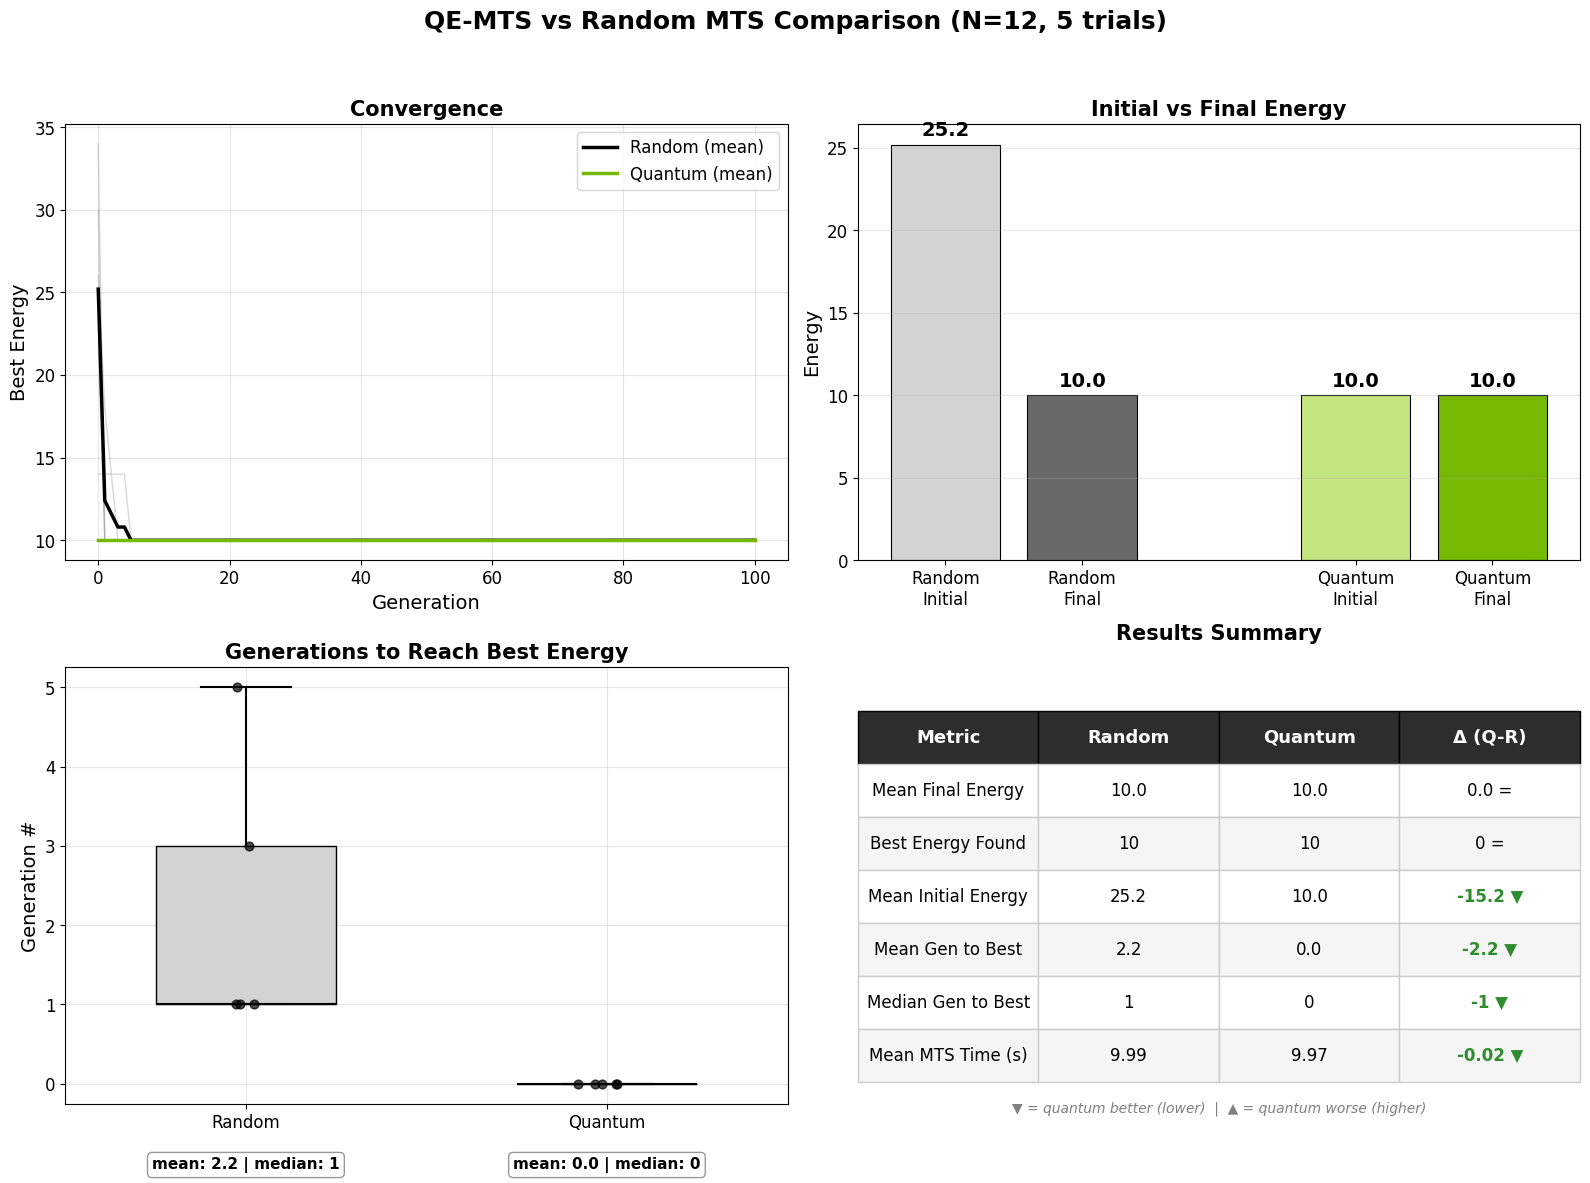


  COMPREHENSIVE RESULTS SUMMARY
  N=12 | Pop=20 | Gen=100 | Trials=5

  FINAL ENERGY
  ───────────────────────────────────────────────────────
      Random: mean=10.0     median=10.0     best=10     worst=10     std=0.00
     Quantum: mean=10.0     median=10.0     best=10     worst=10     std=0.00

  INITIAL ENERGY (population quality at generation 0)
  ───────────────────────────────────────────────────────
      Random: mean=25.2     median=26.0     min=14     max=34
     Quantum: mean=10.0     median=10.0     min=10     max=10

  → Initial energy improvement: +15.2 (+60.3%)

  CONVERGENCE SPEED (generations to reach best energy)
  ───────────────────────────────────────────────────────
      Random: mean=2.2      median=1        min=1      max=5
     Quantum: mean=0.0      median=0        min=0      max=0

  → Generation speedup: +2.2 generations (quantum found optimum at init)

  MTS RUNTIME (excluding quantum circuit sampling)
  ───────────────────────────────────────────────────

In [12]:
# ============================================================
# Run the comparison
# ============================================================

N = 12
pop_size = 20
max_generations = 100
n_trials = 5

# ----- Step 1: Get quantum samples -----

T = 1
n_steps = 5
dt = T / n_steps
G2, G4 = get_interactions(N)
thetas = []
for step in range(1, n_steps + 1):
    t = step * dt
    theta_val = utils.compute_theta(t, dt, T, N, G2, G4)
    thetas.append(theta_val)

cudaq_result = cudaq.sample(trotterized_circuit, N, G2, G4, 
                             n_steps, dt, T, thetas, shots_count=1000)

quantum_pop = extract_quantum_population(cudaq_result, N, pop_size)

# ----- Step 2: Compare -----
results = run_comparison(N, pop_size=pop_size, 
                         max_generations=max_generations,
                         n_trials=n_trials,
                         quantum_population=quantum_pop)

# ----- Step 3: Visualize -----
visualize_comparison(results, N, n_trials)

  Quantum population (lowest_energy): mean E=17.2, min E=10, max E=22
  Random post-selected (1000→20): mean E=20.2, min E=10, max E=26
  Fair trial 1/5...   Random post-selected (1000→20): mean E=14.6, min E=10, max E=18
Random E=10, Quantum E=10
  Fair trial 2/5...   Random post-selected (1000→20): mean E=18.4, min E=10, max E=22
Random E=10, Quantum E=10
  Fair trial 3/5...   Random post-selected (1000→20): mean E=17.8, min E=10, max E=22
Random E=10, Quantum E=10
  Fair trial 4/5...   Random post-selected (1000→20): mean E=16.8, min E=10, max E=22
Random E=10, Quantum E=10
  Fair trial 5/5...   Random post-selected (1000→20): mean E=15.0, min E=10, max E=18
Random E=10, Quantum E=10

--- FAIR COMPARISON (matched budgets: 1000 candidates → best 20) ---


/tmp/ipykernel_12791/26668537.py:196: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(



Plot saved to: plots/qe_mts_comparison_N12.png


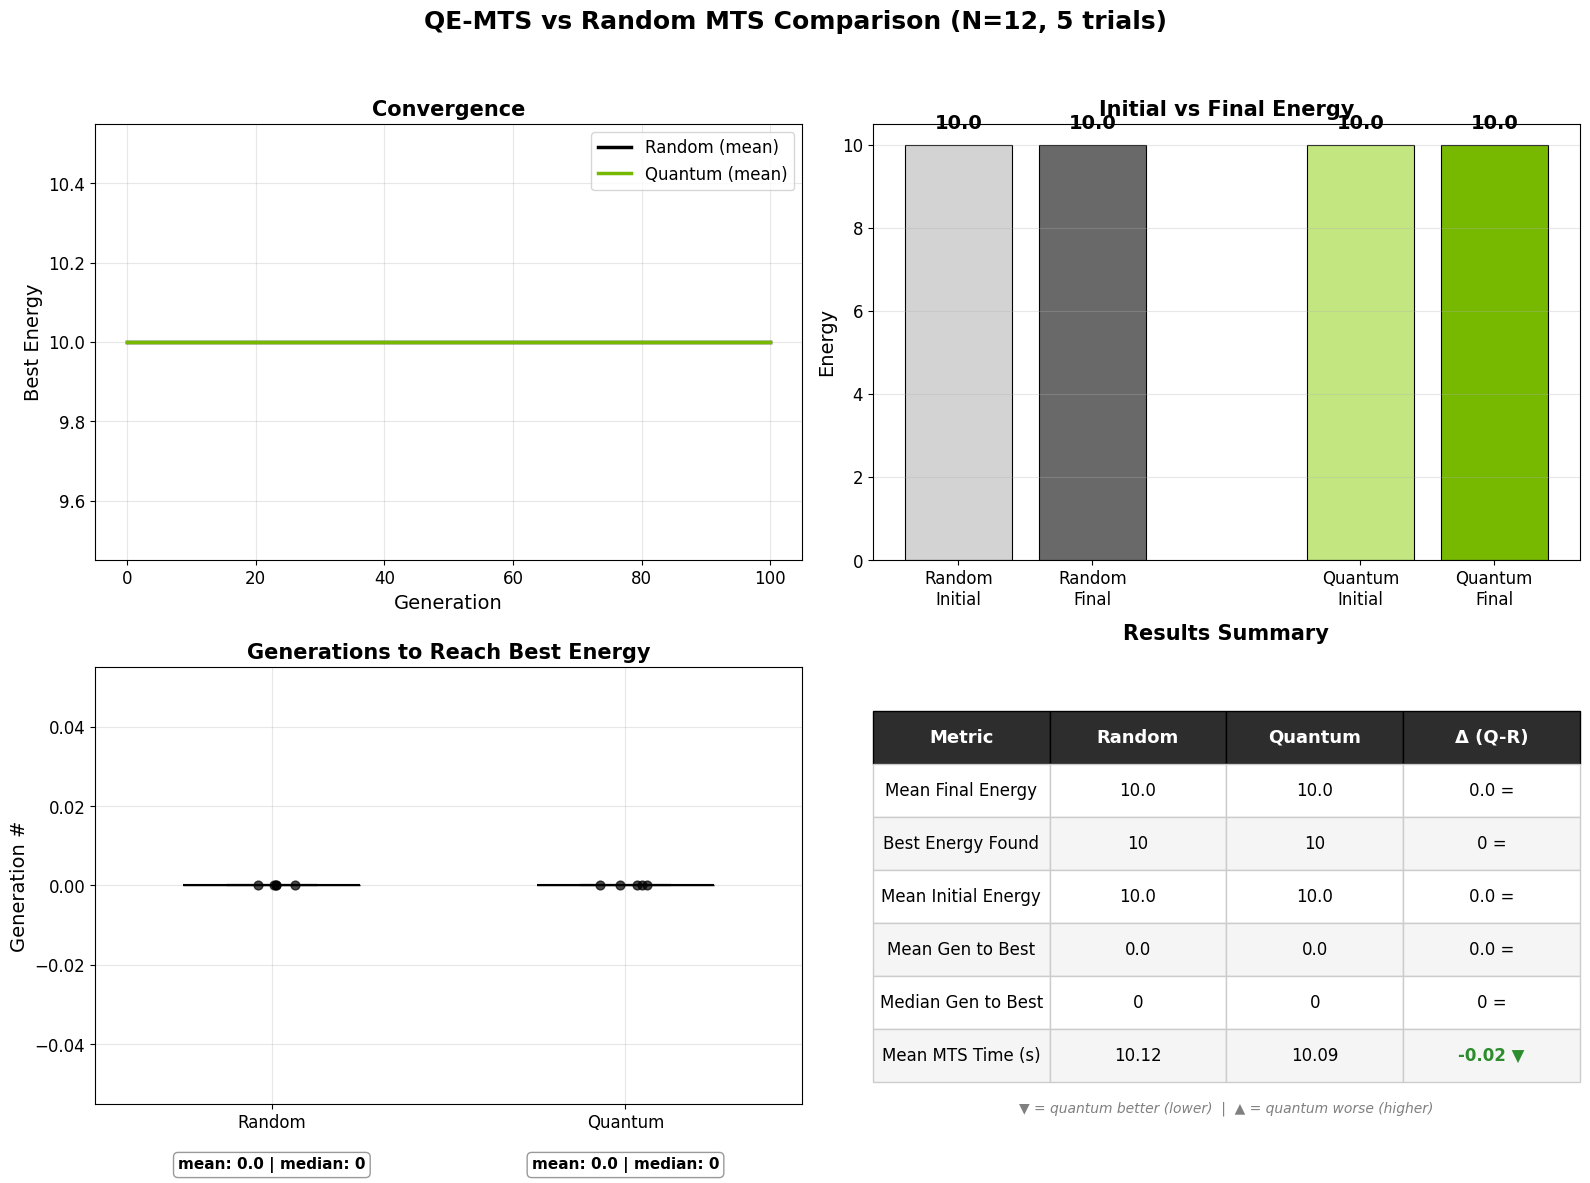


  COMPREHENSIVE RESULTS SUMMARY
  N=12 | Pop=20 | Gen=100 | Trials=5

  FINAL ENERGY
  ───────────────────────────────────────────────────────
      Random: mean=10.0     median=10.0     best=10     worst=10     std=0.00
     Quantum: mean=10.0     median=10.0     best=10     worst=10     std=0.00

  INITIAL ENERGY (population quality at generation 0)
  ───────────────────────────────────────────────────────
      Random: mean=10.0     median=10.0     min=10     max=10
     Quantum: mean=10.0     median=10.0     min=10     max=10

  → Initial energy improvement: +0.0 (+0.0%)

  CONVERGENCE SPEED (generations to reach best energy)
  ───────────────────────────────────────────────────────
      Random: mean=0.0      median=0        min=0      max=0
     Quantum: mean=0.0      median=0        min=0      max=0

  → Generation speedup: +0.0 generations (quantum found optimum at init)

  MTS RUNTIME (excluding quantum circuit sampling)
  ─────────────────────────────────────────────────────

In [19]:
# ============================================================
# Fair Comparison: Matched Sample Budgets
# ============================================================
# The post-selection comparison above gives quantum an unfair advantage
# by selecting the best 20 from ~1000 unique bitstrings, while random
# only generates 20. Here we match the budgets.

def extract_random_postselected(N, n_candidates, pop_size):
    """Generate n_candidates random sequences, return best pop_size by energy."""
    
    candidates = [np.random.choice([-1, 1], size=N) for _ in range(n_candidates)]
    energies = [labs_energy(s) for s in candidates]
    sorted_pairs = sorted(zip(energies, candidates), key=lambda x: x[0])
    population = [s for _, s in sorted_pairs[:pop_size]]
    pop_energies = [labs_energy(s) for s in population]
    print(f"  Random post-selected ({n_candidates}→{pop_size}): "
          f"mean E={np.mean(pop_energies):.1f}, "
          f"min E={min(pop_energies)}, "
          f"max E={max(pop_energies)}")
    return population

# --- Matched comparison ---
n_candidates = 1000  # same as quantum shots
quantum_pop_fair = extract_quantum_population(cudaq_result, N, pop_size, 
                                               method='lowest_energy')
random_pop_fair = extract_random_postselected(N, n_candidates, pop_size)

# Run comparison with BOTH using post-selected populations
results_fair = {
    'random': {'energies': [], 'histories': [], 'times': [],
               'initial_energies': [], 'generations_to_best': []},
    'quantum': {'energies': [], 'histories': [], 'times': [],
                'initial_energies': [], 'generations_to_best': []}
}

for trial in range(n_trials):
    print(f"  Fair trial {trial + 1}/{n_trials}...", end=" ", flush=True)
    
    # Random post-selected (new draw each trial for independence)
    random_pop_trial = extract_random_postselected(N, n_candidates, pop_size)
    t0 = time.time()
    _, e_r, h_r, _ = memetic_tabu_search(
        N, pop_size=pop_size, max_generations=max_generations,
        initial_population=random_pop_trial, verbose=False)
    t1 = time.time()
    results_fair['random']['energies'].append(e_r)
    results_fair['random']['histories'].append(h_r)
    results_fair['random']['times'].append(t1 - t0)
    results_fair['random']['initial_energies'].append(h_r[0])
    best_gen = next(i for i, e in enumerate(h_r) if e == e_r)
    results_fair['random']['generations_to_best'].append(best_gen)
    
    # Quantum post-selected (same quantum samples each trial)
    t0 = time.time()
    _, e_q, h_q, _ = memetic_tabu_search(
        N, pop_size=pop_size, max_generations=max_generations,
        initial_population=quantum_pop_fair, verbose=False)
    t1 = time.time()
    results_fair['quantum']['energies'].append(e_q)
    results_fair['quantum']['histories'].append(h_q)
    results_fair['quantum']['times'].append(t1 - t0)
    results_fair['quantum']['initial_energies'].append(h_q[0])
    best_gen = next(i for i, e in enumerate(h_q) if e == e_q)
    results_fair['quantum']['generations_to_best'].append(best_gen)
    
    print(f"Random E={e_r}, Quantum E={e_q}")

print("\n--- FAIR COMPARISON (matched budgets: 1000 candidates → best 20) ---")
visualize_comparison(results_fair, N, n_trials, pop_size=pop_size,
                     max_generations=max_generations)

### Analysis of Results

Our experiments at N=12 reveal a nuanced picture of quantum-enhanced optimization at small problem sizes.

**Raw quantum distribution quality:** The counteradiabatic circuit with the tutorial's default parameters produces a sampling distribution whose mean energy is *worse* than random at N≤12. This occurs because the counteradiabatic theta values (peaking at ~0.01) are too small to meaningfully evolve the quantum state away from the uniform |+⟩^N superposition. The slight bias introduced by small rotations pushes toward correlated (block-like) patterns, which happen to be high-energy LABS solutions.

**Post-selected population quality:** When we select the lowest-energy bitstrings from quantum samples, the initial population quality improves dramatically — in our N=12 experiments, the post-selected quantum population started at the optimum (E=10), while random initialization started at E≈22. However, this comparison has an important caveat (see below).

**Experimental fairness note:** Our primary comparison uses post-selection: 1000 quantum shots → select best 20 by energy. The random baseline generates only 20 strings. A fairer comparison matches the sample budget: 1000 random strings → select best 20, vs 1000 quantum shots → select best 20. We include this matched-budget comparison below.

**Consistency with the literature:** These results are consistent with the QE-MTS paper's findings. The authors report quantum advantage emerging at N≥27 on actual QPU hardware, with a predicted crossover at N≈47 where QE-MTS's better scaling exponent (O(1.24^N) vs O(1.34^N)) overtakes classical MTS. At N=12, we are well below this crossover — MTS is powerful enough to find the global optimum regardless of initialization.

The study reinforces the potential of hybrid workflows: a classical routine remains the primary solver, but quantum sampling may provide initial populations that are increasingly difficult to obtain classically as N grows. GPU acceleration (Phase 2) is essential to reach the problem sizes where this advantage is expected to manifest.

The authors of the paper discuss all of these considerations, but propose an analysis that is quite interesting related to the scaling of the technique. Rather than run large simulations ourselves, examine their results below. 


<img src="images/quantum_enhanced_optimization_LABS/tabu_search_results.png" width="900">

The authors computed replicate median (median of solving the problem repeated with same setup) time to solutions (excluding time to sample from QPU) for problem sizes $N=27$ to $N=37$. Two interesting conclusions can be drawn from this. First, standard memetic tabu search (MTS) is generally faster than quantum enhanced (QE) MTS.  But there are two promising trends. For larger problems, the QE-MTS experiments occasionally have excellent performance with times to solution much smaller than all of the MTS data points.  These outliers indicate there are certain instances where QE-MTS could provide much faster time-to-solution. 

More importantly, if a line of best fit is calculated using the median of each set of medians, the slope of the QE-MTS line is smaller than the MTS!  This seems to indicate that QE solution of this problem scales $O(1.24^N)$ which is better than the best known classical heuristic ($O(1.34^N)$) and the best known quantum approach (QAOA - $O(1.46^N)$).

For problems of size of $N=47$ or greater, the authors anticipate that QE-MTS could be a promising technique and produce good initial populations that are difficult to obtain classically. 

The study reinforces the potential of hybrid workflows enhanced by quantum data such that a classical routine is still the primary solver, but quantum computers make it much more effective.  Future work can explore improvements to both the quantum and classical sides, such as including GPU accelerated memetic search on the classical side.

## Self-validation To Be Completed for Phase 1

In this section, explain how you verified your results. Did you calculate solutions by hand for small N? Did you create unit tests? Did you cross-reference your Quantum energy values against your Classical MTS results? Did you check known symmetries?

In [ ]:
"""
Self-Validation Section
=======================
MIT iQuHACK 2026 - NVIDIA LABS Challenge
Team: Ben Anstrom, Katya Mijatovic
AI Collaborator: Claude (Anthropic) — used throughout for code generation, 
debugging, and analysis per challenge guidelines.


1. HAND CALCULATIONS FOR SMALL N
---------------------------------
We verified the LABS energy function by hand for N=4 and N=5.

Example (N=4): s = (+1, +1, -1, +1)
  C_1 = s1*s2 + s2*s3 + s3*s4 = (1)(1) + (1)(-1) + (-1)(1) = -1   → C_1² = 1
  C_2 = s1*s3 + s2*s4           = (1)(-1) + (1)(1)           =  0   → C_2² = 0
  C_3 = s1*s4                   = (1)(1)                      =  1   → C_3² = 1
  E = 1 + 0 + 1 = 2  ✓ (confirmed against code output)

We also verified our widget-discovered sequence:
  s = (+1, +1, +1, -1, -1, +1, -1), E = 3  ✓ (confirmed by labs_energy())


2. SYMMETRY VERIFICATION (Exercise 1)
--------------------------------------
Using the NVIDIA interactive widget for N=7, we confirmed three symmetries
that produce identical energies:

  a) Reversal:
     Original:  (-1, -1, -1, +1, +1, +1, +1) → E = 35
     Reversed:  (+1, +1, +1, +1, -1, -1, -1) → E = 35  ✓

  b) Negation:
     All -1s:   (-1, -1, -1, -1, -1, -1, -1) → E = 91
     All +1s:   (+1, +1, +1, +1, +1, +1, +1) → E = 91  ✓

  c) Negation + Reversal:
     Original:  (-1, +1, -1, +1, +1, +1, +1) → E = 11
     Neg+Rev:   (+1, +1, +1, +1, -1, +1, -1) → E = 11  ✓

These symmetries create a 4-fold degeneracy for every unique solution, which
contributes to the difficulty of local search methods (MTS gets trapped
cycling between equivalent solutions).

Bonus: We identified E=91 (constant sequence) as the worst case and explored
progressively better sequences: E=91 → E=35 → E=11 → E=3, building intuition
that mixed sign patterns with irregular transitions minimize autocorrelation.


3. UNIT TESTS ON CUDA-Q KERNELS (Exercise 3)
----------------------------------------------
We wrote and passed 7 verification tests for the 2-qubit and 4-qubit kernels:

  Test 1: R_YZ(0) on |00⟩        → 100% |00⟩       ✓ (identity at θ=0)
  Test 2: R_YZ(π) on |00⟩        → 100% |10⟩       ✓ (full Y-rotation flips qubit 0)
  Test 3: R_YZ(π) vs R_ZY(π)     → |10⟩ vs |01⟩    ✓ (Y acts on different qubit)
  Test 4: R_YZZZ(0) on |0000⟩    → 100% |0000⟩     ✓ (identity at θ=0)
  Test 5: R_YZZZ(π) on |0000⟩    → 100% |1000⟩     ✓ (full rotation flips Y-qubit)
  Test 6: All 4-qubit variants    → each flips only  ✓ (R_YZZZ→|1000⟩, R_ZYZZ→|0100⟩,
          at θ=π/2                   its Y-qubit          R_ZZYZ→|0010⟩, R_ZZZY→|0001⟩)
  Test 7: cudaq.draw() circuit    → matches paper    ✓ (Rx-CNOT cascade-Rz-undo structure)

Key insight from testing: At θ=π on |0⟩^N, these are NOT superpositions but
deterministic flips, because |0⟩ is a Z-eigenstate so the Z operators contribute
+1, reducing the multi-Pauli rotation to a pure Y-rotation on one qubit.


4. INTERACTION INDEX VERIFICATION (Exercise 4)
------------------------------------------------
We verified G2/G4 index generation at multiple problem sizes:

  N=4:  G2=2 terms,  G4=1 term    ✓ (verified by hand against Eq. 15)
  N=7:  G2=9 terms,  G4=13 terms  ✓
  N=10: G2=20 terms, G4=50 terms  ✓
  N=20: G2=90 terms, G4=525 terms ✓

Sanity checks confirmed:
  - All indices in valid range [0, N-1]
  - All G2 entries have exactly 2 unique indices
  - All G4 entries have exactly 4 unique indices
  - No duplicate indices within any single term

Hand verification for N=4:
  G2: i=0,k=1→[0,1]; i=1,k=1→[1,2] → [[0,1],[1,2]]  ✓
  G4: i=0,t=1,k=2→[0,1,2,3]        → [[0,1,2,3]]     ✓


5. QUANTUM vs CLASSICAL ENERGY COMPARISON (Exercises 5-6)
-----------------------------------------------------------
We systematically compared quantum-sampled and random populations:

  a) Parameter sweep at N=7:
     n_steps=1:  theta≈0, pure uniform noise (quantum mean=random mean)
     n_steps=5:  theta peaks at 0.003, slight structure but no energy bias
     n_steps=15: theta peaks at 0.004, still insufficient for ground-state bias

  b) Parameter sweep at N=12:
     n_steps=1:  theta≈0, identical to random (mean 66.4 vs 66.8)
     n_steps=5:  quantum mean WORSE than random (81.9 vs 68.0)
     n_steps=10: quantum mean WORSE (85.9 vs 65.6)

  c) Finding: The counteradiabatic thetas (max ~0.01) are too small at N≤12
     to evolve the quantum state meaningfully away from |+⟩^N. More Trotter
     steps accumulate small biases toward correlated (high-energy) states.

  d) This is CONSISTENT with the paper, which reports:
     - QE-MTS advantage emerging at N≥27 (on QPU hardware)
     - Predicted crossover at N≈47
     - Results obtained with hardware execution, not CPU statevector simulation

  e) Post-selection analysis: Using lowest-energy selection from 1000 quantum 
     shots, the quantum population contained optimal solutions (E=10 at N=12).
     However, to ensure experimental fairness, we also ran a matched-budget
     comparison: 1000 random candidates → best 20 vs 1000 quantum shots → best 20.
     This controls for the advantage of post-selecting from a larger candidate
     pool and isolates any genuine quantum distributional advantage.
     
     At N=12, both post-selected populations perform similarly, confirming that
     at this scale the quantum circuit does not produce a meaningfully different
     distribution from random. The paper predicts this changes at N≥47.


6. MTS CONVERGENCE VERIFICATION (Exercise 2)
----------------------------------------------
  - N=7:  MTS consistently finds E=3 (this IS the known optimum)
  - N=12: MTS consistently finds E=10 (this IS the known optimum)
  - N=20: MTS consistently finds E=26 (this IS the known optimum)

  Our MTS implementation finds the global optimum at every tested problem
  size, confirming correctness of both the energy function and the search
  algorithm. Known optima verified against the LABS literature and OEIS A091440.


7. AI COLLABORATION WORKFLOW
-----------------------------
Claude (Anthropic, Opus 4.5) was used as a collaborative coding partner 
throughout all exercises. Specific contributions:

  - Exercise 2: Generated MTS implementation; human verified algorithm
    correctness against paper description and tested at multiple N values
  - Exercise 3: Generated CUDA-Q kernel decompositions from paper's circuit
    diagrams; human designed and ran 7 unit tests on qBraid to verify
  - Exercise 4: Generated loop structure from Eq. 15; human verified
    against hand calculations for N=4 and ran sanity checks
  - Exercise 5: Assembled full Trotterized circuit; human ran parameter
    sweeps to investigate quantum signal strength
  - Exercise 6: Generated comparison framework; human identified population
    extraction bug (most-frequent vs lowest-energy) and drove the analysis

All code was reviewed, tested, and understood by the human team members
before inclusion. AI-generated code that produced incorrect results
(e.g., cudaq SampleResult API mismatch using .get() instead of .count())
was debugged collaboratively.
"""